In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from datetime import timedelta

import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("CUSTOMER-LEVEL SUBSIDY ANALYSIS")
print("="*80)

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

CUSTOMER-LEVEL SUBSIDY ANALYSIS
Loaded data: 34,014 quotes from 23,888 customers


In [2]:
def aggregate_customer(df):
    """
    Single, comprehensive customer-level aggregation for all analyses
    """
    # First, create all necessary quote-level columns
    df = df.copy()
    
    # Create positive subsidy amount (MONEY CUSTOMER ACTUALLY RECEIVES)
    df['positive_cee'] = df['mt_prime_cee'].clip(lower=0)
    df['positive_maprimerenov'] = df['mt_prime_maprimerenov'].clip(lower=0)
    df['positive_subsidy'] = df['positive_cee'] + df['positive_maprimerenov']
    
    # OUT_OF_POCKET: What customer actually pays after subsidies
    df['out_of_pocket'] = df['mt_ttc_avant_aide_devis'] - df['positive_subsidy']
    
    # Subsidy flags (negative values = adjustments/clawbacks)
    df['subsidy_issue'] = (df['mt_prime_cee'] < 0) | (df['mt_prime_maprimerenov'] < 0)
    df['subsidy_issue_cee'] = df['mt_prime_cee'] < 0
    df['subsidy_issue_maprimerenov'] = df['mt_prime_maprimerenov'] < 0
    
    # Negative subsidies (adjustments/clawbacks)
    df['negative_cee'] = df['mt_prime_cee'].clip(upper=0).abs()
    df['negative_maprimerenov'] = df['mt_prime_maprimerenov'].clip(upper=0).abs()
    df['total_negative_subsidy'] = df['negative_cee'] + df['negative_maprimerenov']
    
    # Net subsidy
    df['net_subsidy'] = df['mt_prime_cee'] + df['mt_prime_maprimerenov']
    
    # Heat pump flag
    df['is_heat_pump'] = df['famille_equipement_produit'].str.contains('PAC|POMPE|HEAT|POMPE À CHALEUR', case=False, na=False) | \
                          df['type_equipement_produit'].str.contains('PAC|POMPE|HEAT|POMPE À CHALEUR', case=False, na=False)
    
    # Equipment category
    def categorize_equipment(row):
        if pd.isna(row['famille_equipement_produit']):
            return 'Unknown'
        if row['is_heat_pump']:
            return 'Heat Pump'
        if 'Chaudière' in str(row['famille_equipement_produit']):
            return 'Boiler'
        if 'Climatisation' in str(row['famille_equipement_produit']):
            return 'AC'
        if 'Poêle' in str(row['famille_equipement_produit']):
            return 'Stove'
        return 'Other'
    
    df['equipment_category'] = df.apply(categorize_equipment, axis=1)
    
    print("Quote-level columns created:")
    print(f"  - out_of_pocket: {df['out_of_pocket'].notna().sum():,} values")
    print(f"  - subsidy_issue: {df['subsidy_issue'].sum():,} issues ({df['subsidy_issue'].mean():.1%})")
    
    # Group by customer
    customer_data = df.groupby('numero_compte').agg({
        # Conversion
        'fg_devis_accepte': 'max',
        
        # Price metrics (using mt_apres_remise_ht_devis for quote amounts)
        'mt_apres_remise_ht_devis': ['mean', 'min', 'max', 'std', 'count'],
        
        # OUT_OF_POCKET - what customer actually pays (CRITICAL FOR PRICE ANALYSIS)
        'out_of_pocket': ['mean', 'min', 'max', 'std'],
        
        # Price before subsidy
        'mt_ttc_avant_aide_devis': ['mean', 'min', 'max'],
        
        # Dates
        'dt_creation_devis': ['min', 'max'],
        
        # Subsidy info
        'subsidy_issue': 'max',
        'subsidy_issue_cee': 'max',
        'subsidy_issue_maprimerenov': 'max',
        'positive_subsidy': 'sum',
        'total_negative_subsidy': 'sum',
        'net_subsidy': 'sum',
        'mt_prime_cee': 'sum',
        'mt_prime_maprimerenov': 'sum',
        
        # Product info - take mode (most common)
        'equipment_category': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
        'is_heat_pump': 'max',
        'famille_equipement_produit': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
        
        # ===== NEW: BRAND INFO =====
        'marque_produit': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
        
        # Geography
        'nom_region': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
        'nom_agence': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
        
        # Customer type
        'statut_client': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
    })
    
    # Flatten column names
    customer_data.columns = [
        # From mt_apres_remise_ht_devis
        'converted',
        'avg_quote_amount', 'min_quote_amount', 'max_quote_amount', 
        'std_quote_amount', 'total_quotes',
        
        # FROM OUT_OF_POCKET - CRITICAL FOR PRICE ANALYSIS
        'avg_out_of_pocket', 'min_out_of_pocket', 'max_out_of_pocket', 'std_out_of_pocket',
        
        # From mt_ttc_avant_aide_devis
        'avg_price_before_subsidy', 'min_price_before_subsidy', 'max_price_before_subsidy',
        
        # Dates
        'first_quote_date', 'last_quote_date',
        
        # Subsidy flags
        'had_subsidy_issue', 'had_negative_cee', 'had_negative_maprimerenov',
        'total_positive_subsidy', 'total_negative_subsidy', 'net_subsidy',
        'total_cee', 'total_maprimerenov',
        
        # Product info
        'main_equipment_category', 'ever_bought_heat_pump', 'main_product_family',
        
        # ===== NEW: BRAND =====
        'main_brand',
        
        # Geography
        'main_region', 'main_agency',
        
        # Customer type
        'customer_type'
    ]
    
    # Reset index to make numero_compte a column
    customer_data = customer_data.reset_index()
    
    # =========================================================================
    # DERIVED FEATURES - ALL THE COLUMNS WE NEED FOR ANALYSIS
    # =========================================================================
    
    # 1. TIME-BASED METRICS
    customer_data['customer_duration_days'] = (
        pd.to_datetime(customer_data['last_quote_date']) - 
        pd.to_datetime(customer_data['first_quote_date'])
    ).dt.days + 1
    
    # DECISION DAYS - same as duration (for administrative burden)
    customer_data['decision_days'] = customer_data['customer_duration_days']
    
    # 2. PRICE METRICS
    # Price range using out_of_pocket (what customer actually pays)
    customer_data['price_range'] = customer_data['max_out_of_pocket'] - customer_data['min_out_of_pocket']
    
    # Price range using quote amounts (for comparison)
    customer_data['price_range_quotes'] = customer_data['max_quote_amount'] - customer_data['min_quote_amount']
    
    # Price volatility (standard deviation relative to mean)
    customer_data['price_volatility'] = customer_data['std_out_of_pocket'] / customer_data['avg_out_of_pocket'].replace(0, np.nan)
    
    # PRICE CV - coefficient of variation (for administrative burden)
    customer_data['price_cv'] = customer_data['std_out_of_pocket'] / customer_data['avg_out_of_pocket'].replace(0, np.nan)
    
    # 3. QUOTE METRICS
    # QUOTE COUNT - alias for total_quotes
    customer_data['quote_count'] = customer_data['total_quotes']
    
    # Flag for multi-quote customers
    customer_data['multiple_quotes'] = (customer_data['total_quotes'] > 1).astype(int)
    
    # Quote pattern category
    def categorize_quote_pattern(row):
        if row['total_quotes'] == 1:
            return 'Single quote'
        elif row['total_quotes'] == 2:
            return 'Two quotes'
        else:
            return 'Three+ quotes'
    
    customer_data['quote_pattern'] = customer_data.apply(categorize_quote_pattern, axis=1)
    
    # 4. DECISION SPEED CATEGORY
    def categorize_duration(days):
        if days == 1:
            return 'Same day decision'
        elif days <= 7:
            return 'Quick (2-7 days)'
        elif days <= 30:
            return 'Medium (8-30 days)'
        else:
            return 'Long (>30 days)'
    
    customer_data['decision_speed'] = customer_data['customer_duration_days'].apply(categorize_duration)
    
    # 5. SUBSIDY ISSUE TYPE
    def categorize_subsidy_issues(row):
        if row['had_negative_cee'] and row['had_negative_maprimerenov']:
            return 'Both'
        elif row['had_negative_cee']:
            return 'CEE Only'
        elif row['had_negative_maprimerenov']:
            return 'MaPrimeRénov Only'
        else:
            return 'No Issues'
    
    customer_data['subsidy_issue_type'] = customer_data.apply(categorize_subsidy_issues, axis=1)
    
    # 6. TIME-BASED FEATURES FOR SEASONAL ANALYSIS
    customer_data['first_quote_year'] = pd.to_datetime(customer_data['first_quote_date']).dt.year
    customer_data['first_quote_month'] = pd.to_datetime(customer_data['first_quote_date']).dt.month
    customer_data['first_quote_quarter'] = pd.to_datetime(customer_data['first_quote_date']).dt.quarter
    customer_data['year'] = customer_data['first_quote_year']
    customer_data['month'] = customer_data['first_quote_month']
    customer_data['quarter'] = customer_data['first_quote_quarter']
    
    # Season
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Fall'
    
    customer_data['season'] = customer_data['first_quote_month'].apply(get_season)
    
    # Period for year-over-year comparison
    customer_data['period'] = customer_data['first_quote_year'].astype(str)
    
    # Year-quarter for trends
    customer_data['year_quarter'] = customer_data['first_quote_year'].astype(str) + 'Q' + customer_data['first_quote_quarter'].astype(str)
    
    # 7. SUSPENSION FLAG (based on French subsidy suspension dates)
    suspension_start = pd.to_datetime('2025-07-01')
    suspension_end = pd.to_datetime('2025-09-30')
    suspension_start2 = pd.to_datetime('2026-01-01')
    suspension_end2 = pd.to_datetime('2026-01-22')
    
    customer_data['during_suspension'] = (
        (pd.to_datetime(customer_data['first_quote_date']) >= suspension_start) & 
        (pd.to_datetime(customer_data['first_quote_date']) <= suspension_end)
    ) | (
        (pd.to_datetime(customer_data['first_quote_date']) >= suspension_start2) & 
        (pd.to_datetime(customer_data['first_quote_date']) <= suspension_end2)
    )
    
    print(f"\n✅ Customer dataset created: {len(customer_data):,} customers")
    print(f"✅ Total columns: {len(customer_data.columns)}")
    print(f"✅ Key columns now available:")
    print(f"   - decision_days: from customer_duration_days")
    print(f"   - price_cv: from std_out_of_pocket / avg_out_of_pocket") # Price Coefficient of Variation
    print(f"   - quote_count: alias for total_quotes")
    print(f"   - main_brand: most common brand per customer")
    print(f"   - price_range: {customer_data['price_range'].mean():.0f} avg")
    print(f"   - price_volatility: {customer_data['price_volatility'].mean():.2f} avg")
    
    return customer_data

# Use the function
customers = aggregate_customer(df_clean)


# Save
customers.to_csv('customer_master_data.csv', index=False)
print("\n✅ Saved to 'customer_master_data.csv'")

Quote-level columns created:
  - out_of_pocket: 32,057 values
  - subsidy_issue: 8,380 issues (24.6%)

✅ Customer dataset created: 23,888 customers
✅ Total columns: 52
✅ Key columns now available:
   - decision_days: from customer_duration_days
   - price_cv: from std_out_of_pocket / avg_out_of_pocket
   - quote_count: alias for total_quotes
   - main_brand: most common brand per customer
   - price_range: 1101 avg
   - price_volatility: 0.26 avg

✅ Saved to 'customer_master_data.csv'


In [3]:
print(customers['subsidy_issue_type'].value_counts())

subsidy_issue_type
No Issues            17335
Both                  2307
MaPrimeRénov Only     2140
CEE Only              2106
Name: count, dtype: int64


In [4]:
# Customer conversion by subsidy issue status
print("\nCustomer conversion by subsidy issue status:\n")
issue_conv = customers.groupby('had_subsidy_issue')['converted'].agg(['mean', 'count', 'sum'])
issue_conv.columns = ['conversion_rate', 'customer_count', 'converted_count']
print(issue_conv)

# Statistical test
contingency = pd.crosstab(customers['had_subsidy_issue'], customers['converted'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square p-value: {p_value:.6e}") 
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

# Calculate the difference
conv_no_issue = customers[~customers['had_subsidy_issue']]['converted'].mean()
conv_with_issue = customers[customers['had_subsidy_issue']]['converted'].mean()
diff = (conv_with_issue - conv_no_issue) * 100

print(f"\nConversion without issues: {conv_no_issue:.2%}")
print(f"Conversion with issues: {conv_with_issue:.2%}")
print(f"Difference: {diff:.1f} percentage points")


print(f"Customer-level finding: +{diff:.1f} points")


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.362042           17335           6276.0
True                      0.485579            6553           3182.0

Chi-square p-value: 7.601147e-68
Statistically significant: YES

Conversion without issues: 36.20%
Conversion with issues: 48.56%
Difference: 12.4 percentage points
Customer-level finding: +12.4 points


In [5]:
print("\n" + "="*80)
print("DEEPER ANALYSIS: CUSTOMER CHARACTERISTICS BY SUBSIDY ISSUE STATUS")
print("="*80)

# Compare key metrics
metrics = ['total_quotes', 'avg_quote_amount', 'max_quote_amount', 
           'customer_duration_days', 'price_range', 'multiple_quotes']

print("\nMetric comparison:")
for metric in metrics:
    if metric in customers.columns:
        no_issue_mean = customers[~customers['had_subsidy_issue']][metric].mean()
        issue_mean = customers[customers['had_subsidy_issue']][metric].mean()
        ratio = issue_mean / no_issue_mean if no_issue_mean != 0 else 0
        print(f"\n{metric}:")
        print(f"  No issues: {no_issue_mean:.2f}")
        print(f"  With issues: {issue_mean:.2f}")
        print(f"  Ratio: {ratio:.2f}x")

# Add categorical analysis
print("\nQuote pattern distribution by subsidy issue:")
quote_pattern_pivot = pd.crosstab(
    customers['quote_pattern'], 
    customers['had_subsidy_issue'], 
    normalize='columns'
)
print(quote_pattern_pivot.round(3))

print("\nDecision speed by subsidy issue:")
decision_speed_pivot = pd.crosstab(
    customers['decision_speed'], 
    customers['had_subsidy_issue'], 
    normalize='columns'
)
print(decision_speed_pivot.round(3))

# Product family distribution
print("\nProduct family by subsidy issue status:")
product_pivot = pd.crosstab(customers['main_product_family'], 
                            customers['had_subsidy_issue'], 
                            normalize='columns')
print(product_pivot.round(3))

# Conversion by subsidy issue type
print("\nConversion by subsidy issue type:")
type_conv = customers.groupby('subsidy_issue_type')['converted'].agg(['mean', 'count'])
print(type_conv.sort_values('mean', ascending=False))


DEEPER ANALYSIS: CUSTOMER CHARACTERISTICS BY SUBSIDY ISSUE STATUS

Metric comparison:

total_quotes:
  No issues: 1.38
  With issues: 1.53
  Ratio: 1.11x

avg_quote_amount:
  No issues: 6164.43
  With issues: 9935.00
  Ratio: 1.61x

max_quote_amount:
  No issues: 6571.38
  With issues: 10832.75
  Ratio: 1.65x

customer_duration_days:
  No issues: 17.87
  With issues: 24.31
  Ratio: 1.36x

price_range:
  No issues: 868.91
  With issues: 1702.03
  Ratio: 1.96x

multiple_quotes:
  No issues: 0.28
  With issues: 0.36
  Ratio: 1.28x

Quote pattern distribution by subsidy issue:
had_subsidy_issue  False  True 
quote_pattern                  
Single quote       0.722  0.644
Three+ quotes      0.066  0.111
Two quotes         0.212  0.245

Decision speed by subsidy issue:
had_subsidy_issue   False  True 
decision_speed                  
Long (>30 days)     0.070  0.101
Medium (8-30 days)  0.031  0.047
Quick (2-7 days)    0.040  0.063
Same day decision   0.858  0.788

Product family by subsidy 

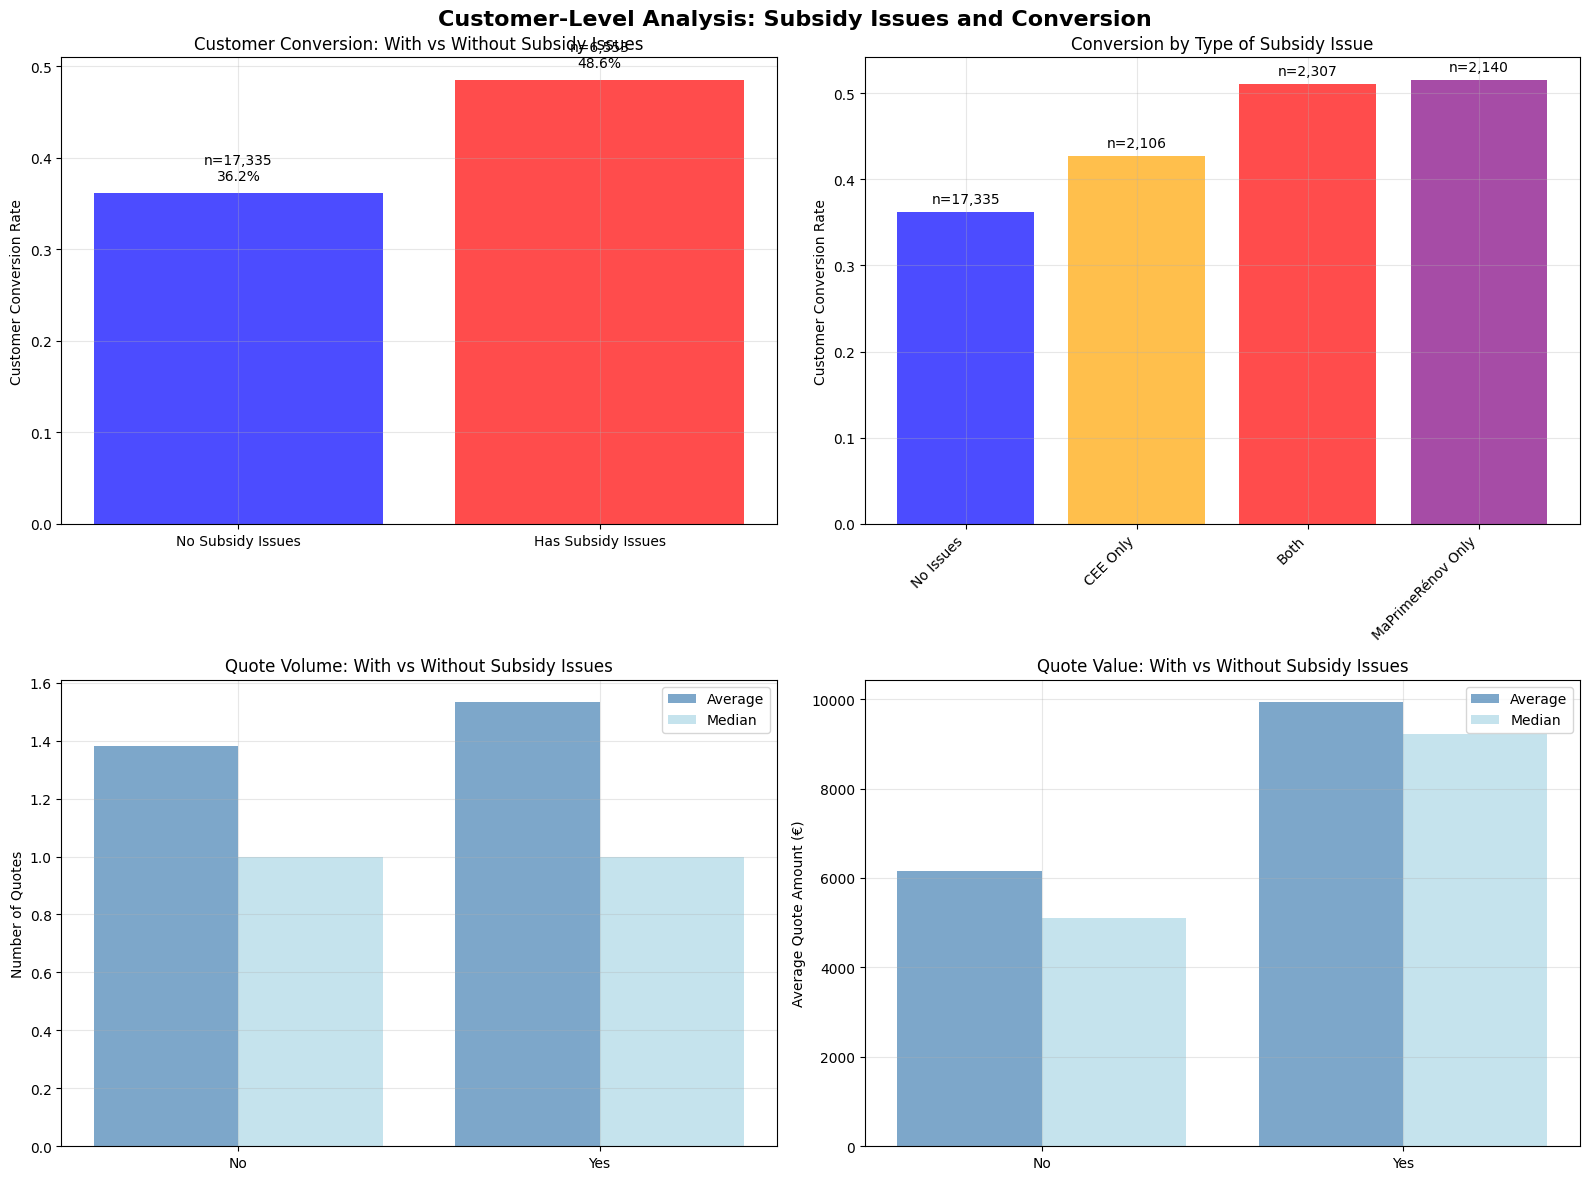

In [6]:
# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer-Level Analysis: Subsidy Issues and Conversion', fontsize=16, fontweight='bold')

# Plot 1: Conversion by subsidy issue status
ax1 = axes[0, 0]
bars = ax1.bar(['No Subsidy Issues', 'Has Subsidy Issues'], 
               [conv_no_issue, conv_with_issue],
               color=['blue', 'red'], alpha=0.7)
ax1.set_ylabel('Customer Conversion Rate')
ax1.set_title('Customer Conversion: With vs Without Subsidy Issues')
ax1.grid(True, alpha=0.3)

# Add counts
for i, (bar, (issue, count)) in enumerate(zip(bars, customers.groupby('had_subsidy_issue').size().items())):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'n={count:,}\n{height:.1%}', ha='center', va='bottom')

# Plot 2: Conversion by subsidy issue type
ax2 = axes[0, 1]
type_conv_mean = customers.groupby('subsidy_issue_type')['converted'].mean().sort_values()
type_counts = customers['subsidy_issue_type'].value_counts()
colors = {'No Issues': 'blue', 'CEE Only': 'orange', 'MaPrimeRénov Only': 'purple', 'Both': 'red'}
bar_colors = [colors.get(x, 'gray') for x in type_conv_mean.index]

bars = ax2.bar(range(len(type_conv_mean)), type_conv_mean.values, color=bar_colors, alpha=0.7)
ax2.set_xticks(range(len(type_conv_mean)))
ax2.set_xticklabels(type_conv_mean.index, rotation=45, ha='right')
ax2.set_ylabel('Customer Conversion Rate')
ax2.set_title('Conversion by Type of Subsidy Issue')
ax2.grid(True, alpha=0.3)

for i, (idx, val) in enumerate(type_conv_mean.items()):
    ax2.text(i, val + 0.01, f'n={type_counts[idx]:,}', ha='center')

# Plot 3: Quote volume comparison
ax3 = axes[1, 0]
quote_data = []
for issue in [False, True]:
    subset = customers[customers['had_subsidy_issue'] == issue]
    quote_data.append({
        'Subsidy Issues': 'Yes' if issue else 'No',
        'Avg Quotes': subset['total_quotes'].mean(),
        'Median Quotes': subset['total_quotes'].median()
    })
quote_df = pd.DataFrame(quote_data)

x = range(len(quote_df))
ax3.bar([i - 0.2 for i in x], quote_df['Avg Quotes'], width=0.4, label='Average', alpha=0.7, color='steelblue')
ax3.bar([i + 0.2 for i in x], quote_df['Median Quotes'], width=0.4, label='Median', alpha=0.7, color='lightblue')
ax3.set_xticks(x)
ax3.set_xticklabels(quote_df['Subsidy Issues'])
ax3.set_ylabel('Number of Quotes')
ax3.set_title('Quote Volume: With vs Without Subsidy Issues')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Price comparison
ax4 = axes[1, 1]
price_data = []
for issue in [False, True]:
    subset = customers[customers['had_subsidy_issue'] == issue]
    price_data.append({
        'Subsidy Issues': 'Yes' if issue else 'No',
        'Avg Price': subset['avg_quote_amount'].mean(),
        'Median Price': subset['avg_quote_amount'].median()
    })
price_df = pd.DataFrame(price_data)

x = range(len(price_df))
ax4.bar([i - 0.2 for i in x], price_df['Avg Price'], width=0.4, label='Average', alpha=0.7, color='steelblue')
ax4.bar([i + 0.2 for i in x], price_df['Median Price'], width=0.4, label='Median', alpha=0.7, color='lightblue')
ax4.set_xticks(x)
ax4.set_xticklabels(price_df['Subsidy Issues'])
ax4.set_ylabel('Average Quote Amount (€)')
ax4.set_title('Quote Value: With vs Without Subsidy Issues')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Unique values in main_product_family:
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire                  103
Emetteur de chauffage  ou chappe      93
Produit VMC                           89
Unknown                               36
Fumisterie                            13
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire 

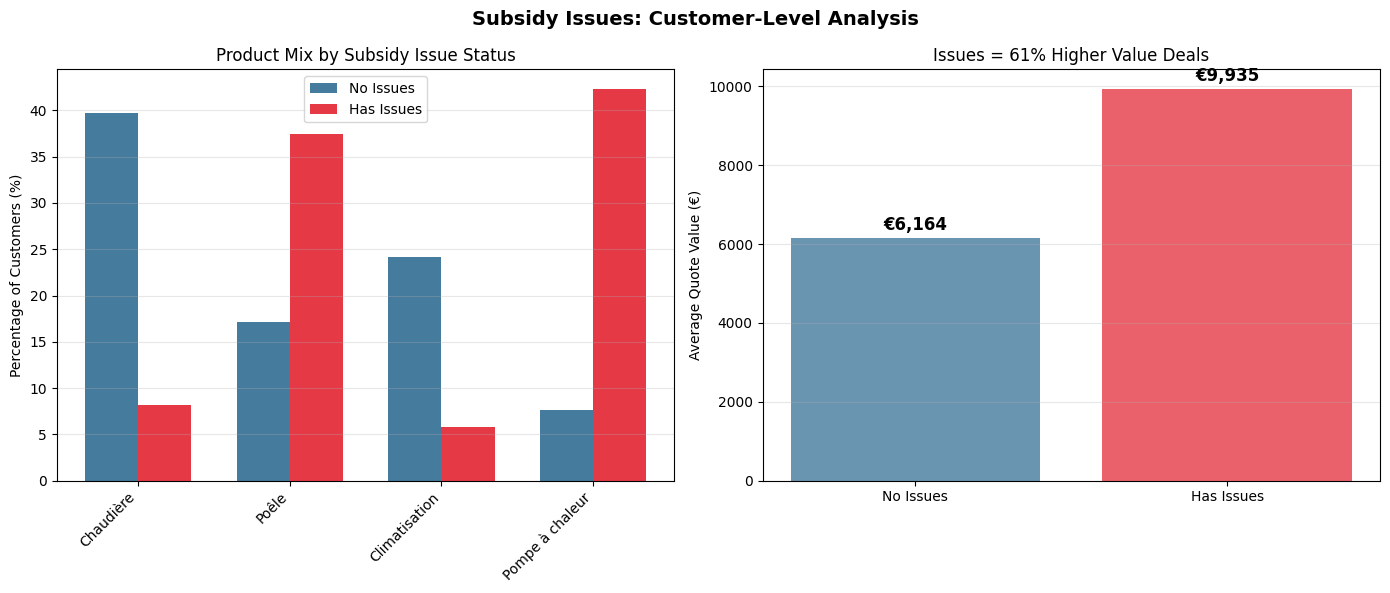

In [7]:
# First, let's see what values actually exist in your data
print("Unique values in main_product_family:")
print(customers['main_product_family'].value_counts())

# Create figure with only 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Subsidy Issues: Customer-Level Analysis', fontsize=14, fontweight='bold')

# Plot 1: Product mix (DYNAMIC) - USING ACTUAL DATA VALUES
ax1 = axes[0]

# Get the top product categories from the actual data
product_counts = customers['main_product_family'].value_counts()
print("\nTop products:")
print(product_counts.head(10))

# Use the actual top products from your data
# Let's take top 4 for clarity
top_products = product_counts.head(4).index.tolist()
print(f"\nUsing these products: {top_products}")

# Calculate percentages for customers WITHOUT subsidy issues
no_issue_customers = customers[~customers['had_subsidy_issue']]
no_issue_pct = []
for product in top_products:
    pct = (no_issue_customers['main_product_family'] == product).mean() * 100
    no_issue_pct.append(pct)

# Calculate percentages for customers WITH subsidy issues
issue_customers = customers[customers['had_subsidy_issue']]
issue_pct = []
for product in top_products:
    pct = (issue_customers['main_product_family'] == product).mean() * 100
    issue_pct.append(pct)

print("\nNo Issue %:", no_issue_pct)
print("Has Issue %:", issue_pct)

x = range(len(top_products))
width = 0.35
ax1.bar([i - width/2 for i in x], no_issue_pct, width, label='No Issues', color='#457b9d')
ax1.bar([i + width/2 for i in x], issue_pct, width, label='Has Issues', color='#e63946')
ax1.set_xticks(x)
ax1.set_xticklabels(top_products, rotation=45, ha='right')
ax1.set_ylabel('Percentage of Customers (%)')
ax1.set_title('Product Mix by Subsidy Issue Status')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Average quote value (DYNAMIC)
ax2 = axes[1]

# Calculate average quote values dynamically
avg_no_issue = customers[~customers['had_subsidy_issue']]['avg_quote_amount'].mean()
avg_with_issue = customers[customers['had_subsidy_issue']]['avg_quote_amount'].mean()
value_diff = (avg_with_issue / avg_no_issue - 1) * 100

bars = ax2.bar(['No Issues', 'Has Issues'], 
               [avg_no_issue, avg_with_issue], 
               color=['#457b9d', '#e63946'], alpha=0.8)
ax2.set_ylabel('Average Quote Value (€)')
ax2.set_title(f'Issues = {value_diff:.0f}% Higher Value Deals')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, [avg_no_issue, avg_with_issue]):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
             f'€{val:,.0f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


THRESHOLD EFFECT

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321


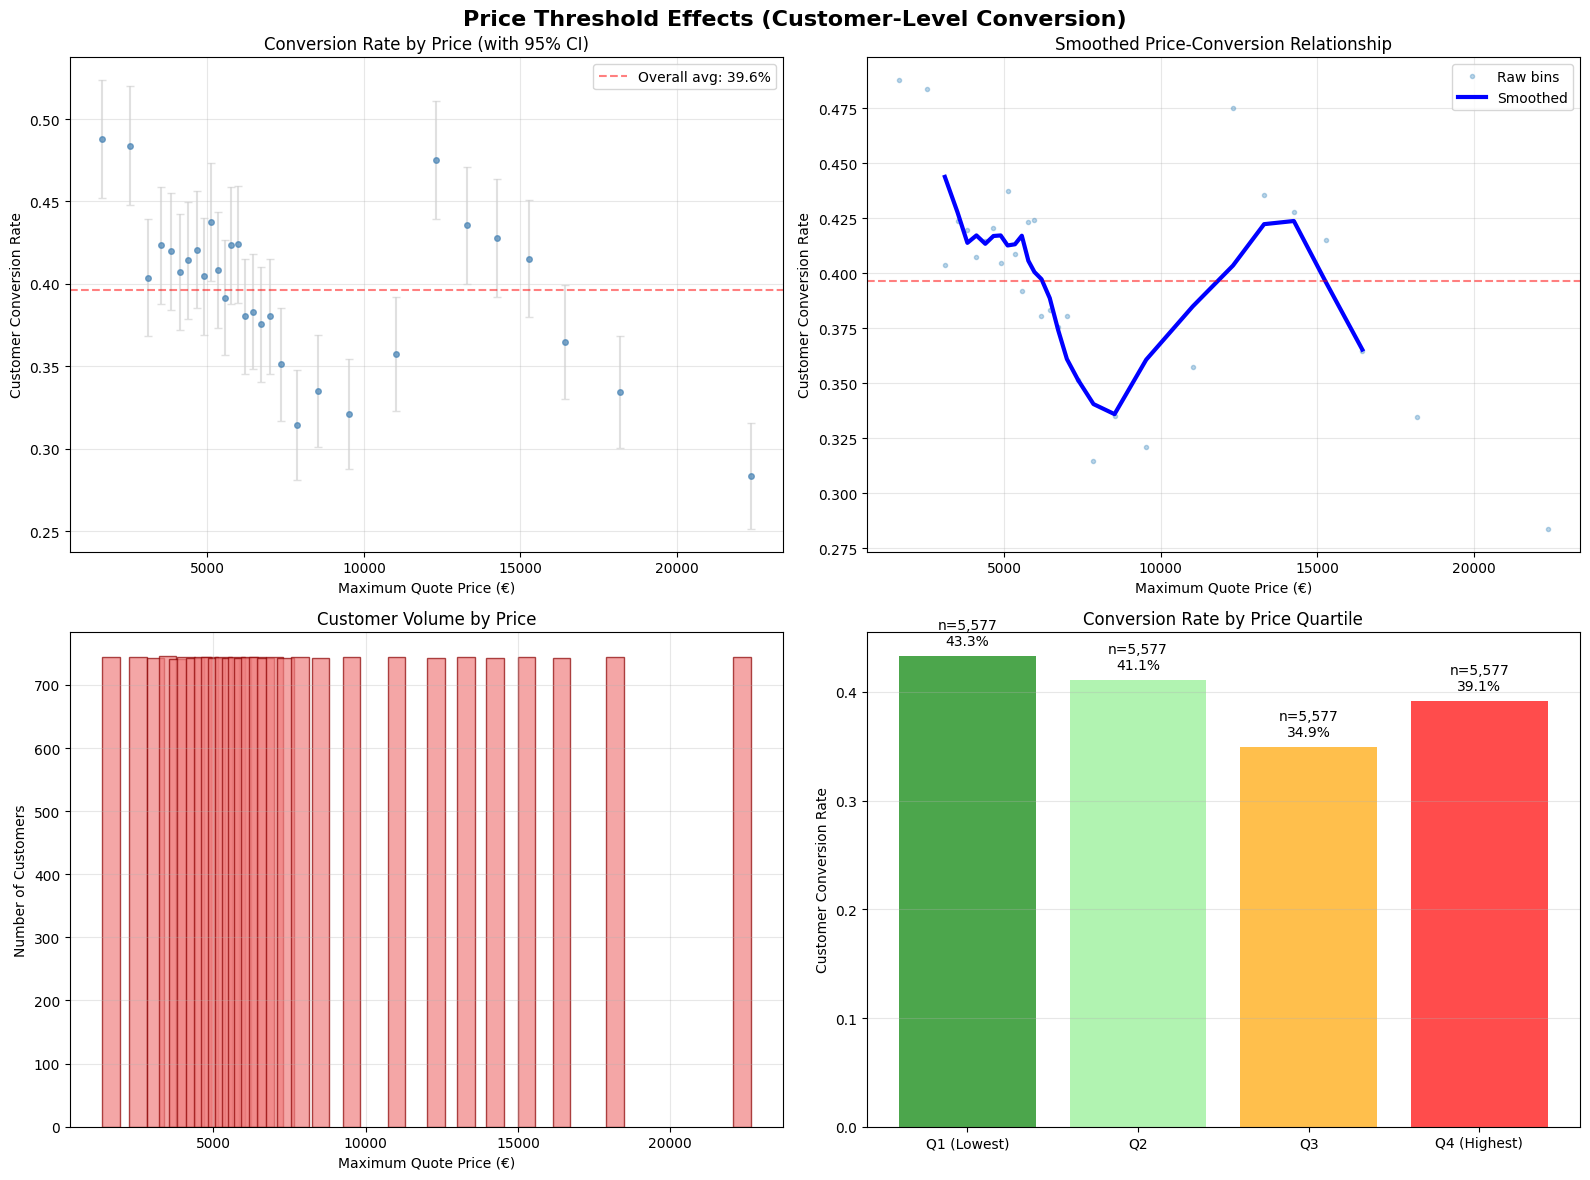


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 43.3% (n=5,577)
  Q2: 41.1% (n=5,577)
  Q3: 34.9% (n=5,577)
  Q4 (Highest): 39.1% (n=5,577)

Difference between lowest and highest quartile: 4.2 percentage points

Sweet spots (above-average conversion):
  €1,643: 48.8% (n=744)
  €2,523: 48.4% (n=744)
  €3,102: 40.4% (n=743)
  €3,506: 42.4% (n=746)
  €3,822: 42.0% (n=741)
  €4,110: 40.7% (n=744)
  €4,393: 41.4% (n=743)
  €4,654: 42.1% (n=744)
  €4,884: 40.5% (n=744)
  €5,107: 43.7% (n=743)
  €5,341: 40.9% (n=744)
  €5,769: 42.3% (n=744)
  €5,963: 42.4% (n=743)
  €12,305: 47.5% (n=743)
  €13,300: 43.5% (n=744)
  €14,250: 42.8% (n=743)
  €15,283: 41.5% (n=744)


In [8]:
print("\n" + "="*80)
print("THRESHOLD EFFECT")
print("="*80)

# Use max_out_of_pocket as the key price variable (highest quote they considered)
price_var = 'max_out_of_pocket'

# Remove extreme outliers for clean visualization
price_lower = customers[price_var].quantile(0.01)
price_upper = customers[price_var].quantile(0.99)
customers_clean = customers[(customers[price_var] >= price_lower) & 
                            (customers[price_var] <= price_upper)].copy()

print(f"\nAnalyzing {len(customers_clean):,} customers")
print(f"Price range: €{customers_clean[price_var].min():,.0f} to €{customers_clean[price_var].max():,.0f}")
print(f"Median price: €{customers_clean[price_var].median():,.0f}")

# Create price bins with equal number of customers
customers_clean['price_bin'] = pd.qcut(customers_clean[price_var], q=30, duplicates='drop')

# Calculate conversion rate per bin
binned_stats = customers_clean.groupby('price_bin').agg({
    'converted': ['mean', 'count', 'sem'],
    price_var: 'mean'
}).round(4)

binned_stats.columns = ['conversion_rate', 'customer_count', 'std_error', 'avg_price']
binned_stats['ci_lower'] = binned_stats['conversion_rate'] - 1.96 * binned_stats['std_error']
binned_stats['ci_upper'] = binned_stats['conversion_rate'] + 1.96 * binned_stats['std_error']
binned_stats = binned_stats.reset_index()

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price Threshold Effects (Customer-Level Conversion)', fontsize=16, fontweight='bold')

# Plot 1: Binned conversion with confidence intervals
ax1 = axes[0, 0]
ax1.errorbar(binned_stats['avg_price'], binned_stats['conversion_rate'], 
             yerr=1.96*binned_stats['std_error'], 
             fmt='o', color='steelblue', ecolor='lightgray', 
             capsize=3, markersize=4, alpha=0.7)
ax1.axhline(y=customers_clean['converted'].mean(), color='red', 
            linestyle='--', alpha=0.5, label=f"Overall avg: {customers_clean['converted'].mean():.1%}")
ax1.set_xlabel('Maximum Quote Price (€)')
ax1.set_ylabel('Customer Conversion Rate')
ax1.set_title('Conversion Rate by Price (with 95% CI)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Smoothed curve
ax2 = axes[0, 1]
window = 5
smoothed = binned_stats['conversion_rate'].rolling(window=window, center=True).mean()
ax2.plot(binned_stats['avg_price'], binned_stats['conversion_rate'], 
         'o', alpha=0.3, markersize=3, label='Raw bins')
ax2.plot(binned_stats['avg_price'], smoothed, 'b-', linewidth=3, label='Smoothed')
ax2.axhline(y=customers_clean['converted'].mean(), color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Maximum Quote Price (€)')
ax2.set_ylabel('Customer Conversion Rate')
ax2.set_title('Smoothed Price-Conversion Relationship')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Volume distribution
ax3 = axes[1, 0]
ax3.bar(binned_stats['avg_price'], binned_stats['customer_count'], 
        width=np.diff(binned_stats['avg_price']).mean()*0.8,
        color='lightcoral', alpha=0.7, edgecolor='darkred')
ax3.set_xlabel('Maximum Quote Price (€)')
ax3.set_ylabel('Number of Customers')
ax3.set_title('Customer Volume by Price')
ax3.grid(True, alpha=0.3)

# Plot 4: Conversion by price quartile
ax4 = axes[1, 1]
customers_clean['price_quartile'] = pd.qcut(customers_clean[price_var], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
quartile_conv = customers_clean.groupby('price_quartile')['converted'].mean()
quartile_counts = customers_clean.groupby('price_quartile').size()

bars = ax4.bar(range(4), quartile_conv.values, color=['green', 'lightgreen', 'orange', 'red'], alpha=0.7)
ax4.set_xticks(range(4))
ax4.set_xticklabels(quartile_conv.index)
ax4.set_ylabel('Customer Conversion Rate')
ax4.set_title('Conversion Rate by Price Quartile')
ax4.grid(True, alpha=0.3, axis='y')

for i, (bar, (idx, count)) in enumerate(zip(bars, quartile_counts.items())):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'n={count:,}\n{height:.1%}', ha='center')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("THRESHOLD EFFECT: KEY FINDINGS")
print("="*80)

print(f"\nConversion by Price Quartile:")
for i, (quartile, conv) in enumerate(quartile_conv.items()):
    print(f"  {quartile}: {conv:.1%} (n={quartile_counts.iloc[i]:,})")

q1_vs_q4 = quartile_conv.iloc[0] - quartile_conv.iloc[-1]
print(f"\nDifference between lowest and highest quartile: {q1_vs_q4*100:.1f} percentage points")

# Check for sweet spots (where conversion is above average)
above_avg = binned_stats[binned_stats['conversion_rate'] > customers_clean['converted'].mean()]
if len(above_avg) > 0:
    print(f"\nSweet spots (above-average conversion):")
    for _, row in above_avg.iterrows():
        print(f"  €{row['avg_price']:,.0f}: {row['conversion_rate']:.1%} (n={row['customer_count']:,})")

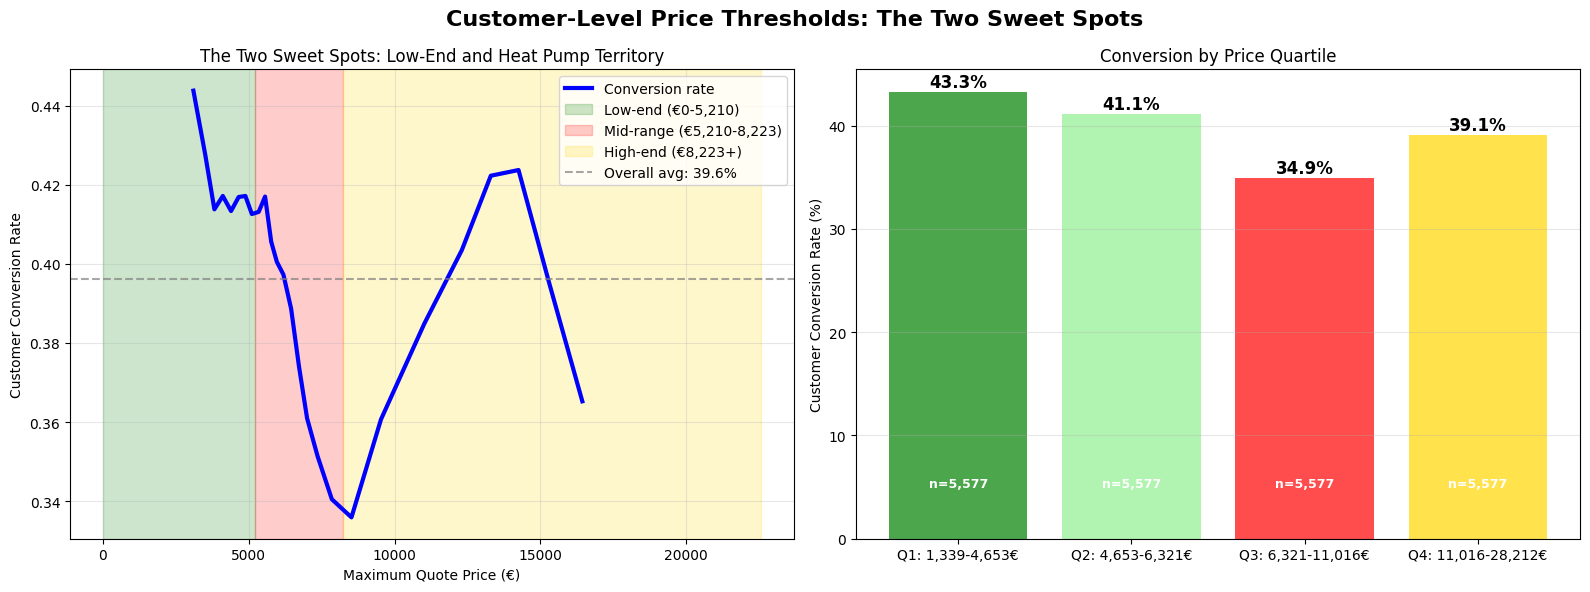


Dynamic quartile calculations:
Quartile boundaries:
  Q1: 1,339€ - 4,653€
  Q2: 4,653€ - 6,321€
  Q3: 6,321€ - 11,016€
  Q4: 11,016€ - 28,212€

Conversion rates: ['43.3%', '41.1%', '34.9%', '39.1%']
Sample sizes: ['5,577', '5,577', '5,577', '5,577']


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer-Level Price Thresholds: The Two Sweet Spots', fontsize=16, fontweight='bold')

# ============================================================================
# PLOT 1: Full curve with highlighted regions
# ============================================================================
ax1 = axes[0]
ax1.plot(binned_stats['avg_price'], smoothed, 'b-', linewidth=3, label='Conversion rate')

# DYNAMIC: Calculate region boundaries from data
price_low_end = customers_clean['max_out_of_pocket'].quantile(0.33)  # Bottom 33%
price_mid_end = customers_clean['max_out_of_pocket'].quantile(0.67)  # Top 33%
price_high_end = customers_clean['max_out_of_pocket'].max() * 0.8    # 80% of max

# Use actual data-driven boundaries instead of hardcoded ones
ax1.axvspan(0, price_low_end, alpha=0.2, color='green', 
            label=f'Low-end (€0-{price_low_end:,.0f})')
ax1.axvspan(price_low_end, price_mid_end, alpha=0.2, color='red', 
            label=f'Mid-range (€{price_low_end:,.0f}-{price_mid_end:,.0f})')
ax1.axvspan(price_mid_end, price_high_end, alpha=0.2, color='gold', 
            label=f'High-end (€{price_mid_end:,.0f}+)')

# Add overall average line (already dynamic)
overall_avg = customers_clean['converted'].mean() * 100
ax1.axhline(y=overall_avg/100, color='gray', 
            linestyle='--', alpha=0.7, label=f'Overall avg: {overall_avg:.1f}%')

ax1.set_xlabel('Maximum Quote Price (€)')
ax1.set_ylabel('Customer Conversion Rate')
ax1.set_title('The Two Sweet Spots: Low-End and Heat Pump Territory')
ax1.grid(True, alpha=0.3)
ax1.legend()

# ============================================================================
# PLOT 2: Bar chart of quartiles with annotations 
# ============================================================================
ax2 = axes[1]

# Calculate everything from data
# Create price quartiles if not already done
if 'price_quartile' not in customers_clean.columns:
    customers_clean['price_quartile'] = pd.qcut(customers_clean['max_out_of_pocket'], 
                                                 q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Get quartile statistics
quartile_stats = customers_clean.groupby('price_quartile').agg({
    'converted': 'mean',
    'max_out_of_pocket': ['min', 'max', 'count']
}).round(3)

# Extract values
quartile_conv = (quartile_stats['converted']['mean'] * 100).values
quartile_counts = quartile_stats['max_out_of_pocket']['count'].values
quartile_mins = quartile_stats['max_out_of_pocket']['min'].values
quartile_maxs = quartile_stats['max_out_of_pocket']['max'].values

# Create dynamic labels with actual price ranges
quartile_labels = []
for i in range(4):
    min_price = quartile_mins[i]
    max_price = quartile_maxs[i]
    quartile_labels.append(f'Q{i+1}: {min_price:,.0f}-{max_price:,.0f}€')

# Colors (can keep these or make dynamic too)
colors = ['green', 'lightgreen', 'red', 'gold']

# Create bars
bars = ax2.bar(quartile_labels, quartile_conv, color=colors, alpha=0.7)
ax2.set_ylabel('Customer Conversion Rate (%)')
ax2.set_title('Conversion by Price Quartile')
ax2.grid(True, alpha=0.3, axis='y')

# Add percentage labels on top of bars
for bar, val in zip(bars, quartile_conv):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Add sample sizes at bottom of bars (DYNAMIC)
for bar, n in zip(bars, quartile_counts):
    ax2.text(bar.get_x() + bar.get_width()/2., 5,
             f'n={n:,}', ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Print the dynamic values for verification
print("\nDynamic quartile calculations:")
print(f"Quartile boundaries:")
for i in range(4):
    print(f"  Q{i+1}: {quartile_mins[i]:,.0f}€ - {quartile_maxs[i]:,.0f}€")
print(f"\nConversion rates: {[f'{c:.1f}%' for c in quartile_conv]}")
print(f"Sample sizes: {[f'{n:,}' for n in quartile_counts]}")

In [10]:
# Create price quartiles in the customer dataset
customers_clean['price_quartile'] = pd.qcut(customers_clean['max_out_of_pocket'], 
                                             q=4, labels=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High'])

# Analyze product mix by quartile
print("\n" + "="*80)
print("PRODUCT MIX BY PRICE QUARTILE")
print("="*80)

product_by_quartile = pd.crosstab(
    customers_clean['price_quartile'], 
    customers_clean['main_equipment_category'],
    normalize='index'
) * 100

print("\nProduct distribution by price quartile (%):")
print(product_by_quartile.round(1))

# Conversion by product and quartile
print("\n" + "="*80)
print("CONVERSION BY PRODUCT AND PRICE QUARTILE")
print("="*80)

for product in ['Heat Pump', 'Boiler', 'AC', 'Stove']:
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 100:
        print(f"\n{product} (n={len(subset):,}):")
        quartile_conv = subset.groupby('price_quartile')['converted'].mean() * 100
        for quartile, conv in quartile_conv.items():
            print(f"  {quartile}: {conv:.1f}%")

# Heat pump specific analysis
hp_customers = customers_clean[customers_clean['ever_bought_heat_pump']]
print("\n" + "="*80)
print("HEAT PUMP CUSTOMERS (n={:,})".format(len(hp_customers)))
print("="*80)

print(f"Average price: €{hp_customers['max_out_of_pocket'].mean():,.0f}")
print(f"Conversion rate: {hp_customers['converted'].mean():.1%}")
print(f"Subsidy issue rate: {hp_customers['had_subsidy_issue'].mean():.1%}")

# Where do heat pumps appear?
hp_by_quartile = customers_clean.groupby('price_quartile')['ever_bought_heat_pump'].mean() * 100
print("\nHeat pump adoption by quartile:")
for quartile, pct in hp_by_quartile.items():
    print(f"  {quartile}: {pct:.1f}%")


PRODUCT MIX BY PRICE QUARTILE

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
price_quartile                                                         
Q1_Low                   25.4    45.2        1.5   16.4   11.5      0.1
Q2_MidLow                14.8    36.0        1.1    2.4   45.6      0.1
Q3_MidHigh               25.2    31.6        4.6    5.7   32.7      0.1
Q4_High                  14.8    12.1       63.9    7.1    1.9      0.2

CONVERSION BY PRODUCT AND PRICE QUARTILE

Heat Pump (n=3,957):
  Q1_Low: 48.1%
  Q2_MidLow: 39.0%
  Q3_MidHigh: 55.1%
  Q4_High: 42.9%

Boiler (n=6,971):
  Q1_Low: 45.9%
  Q2_MidLow: 40.3%
  Q3_MidHigh: 38.7%
  Q4_High: 37.0%

AC (n=4,474):
  Q1_Low: 36.9%
  Q2_MidLow: 30.1%
  Q3_MidHigh: 28.2%
  Q4_High: 31.3%

Stove (n=5,112):
  Q1_Low: 48.4%
  Q2_MidLow: 45.6%
  Q3_MidHigh: 34.8%
  Q4_High: 33.0%

HEAT PUMP CUSTOMERS (n=4,413)
Average price: €14,995
Conversion rate: 43.6%
Subsidy iss


SEGMENT EFFECT


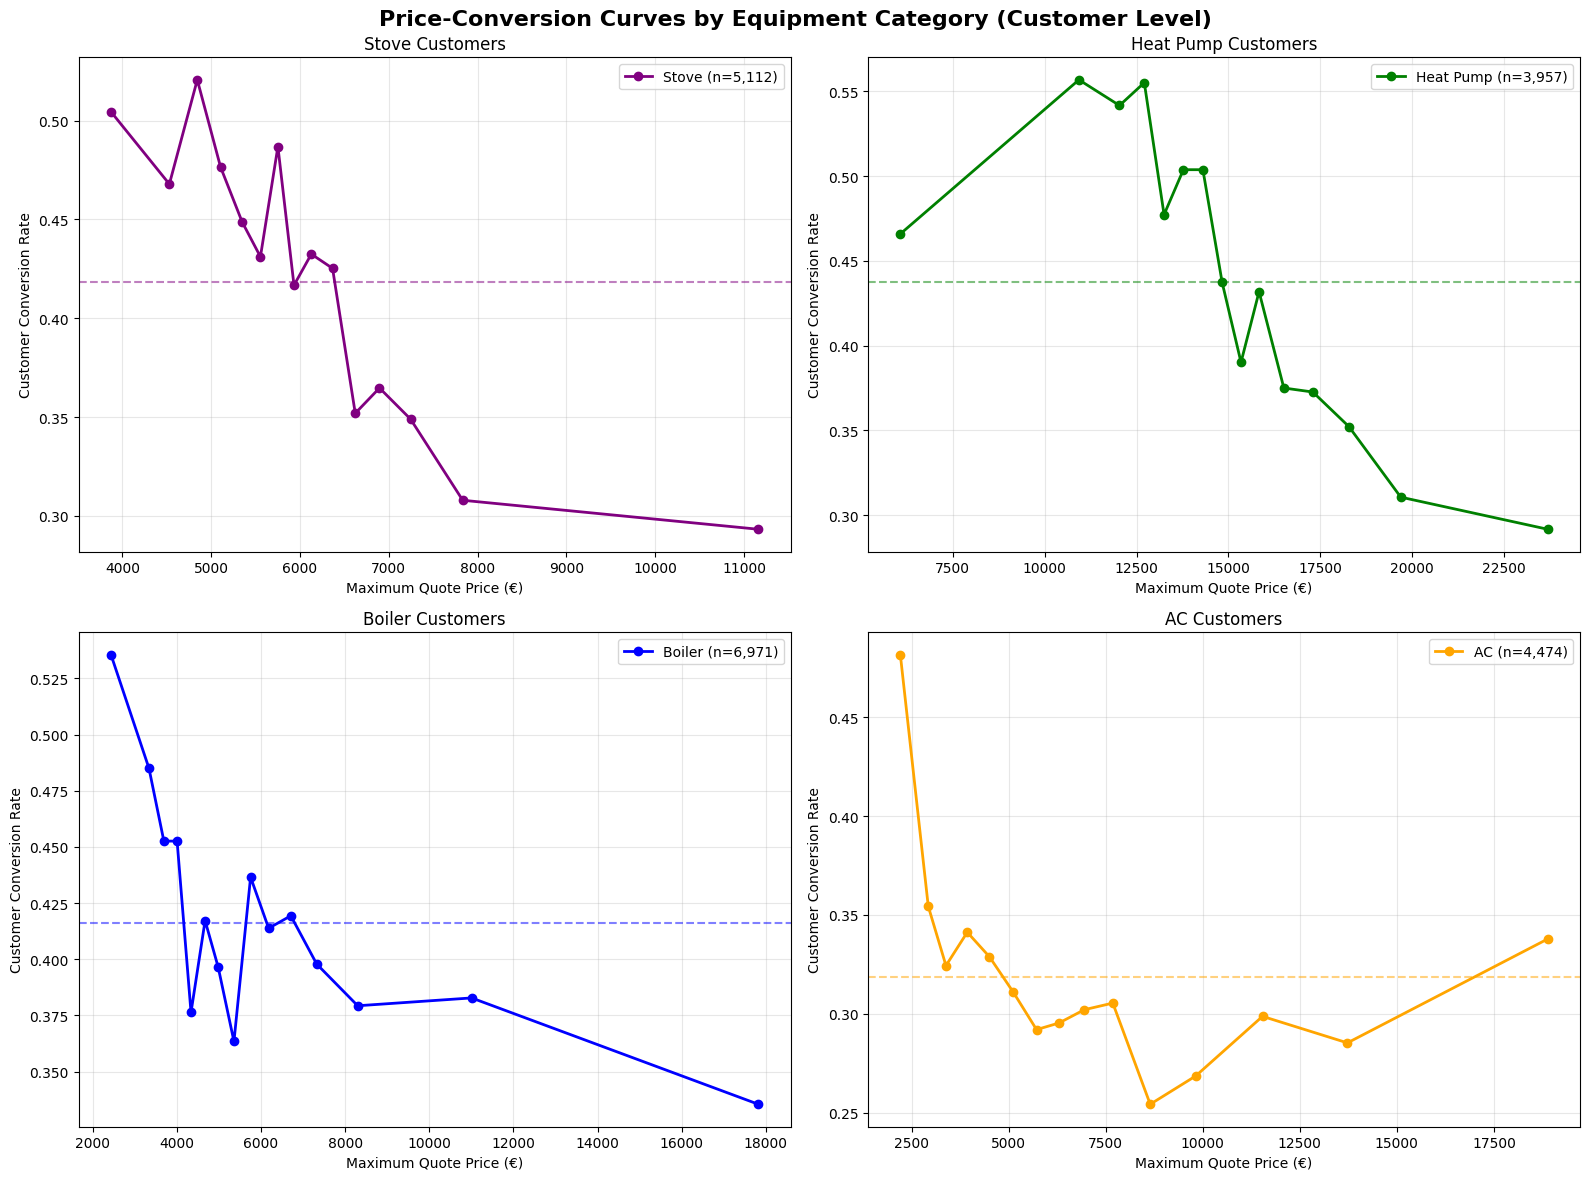

In [11]:
print("\n" + "="*80)
print("SEGMENT EFFECT")
print("="*80)

# Segment 1: By equipment category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price-Conversion Curves by Equipment Category (Customer Level)', fontsize=16, fontweight='bold')

products = ['Stove', 'Heat Pump', 'Boiler', 'AC']
colors = ['purple', 'green', 'blue', 'orange']

for idx, (product, color) in enumerate(zip(products, colors)):
    ax = axes[idx // 2, idx % 2]
    
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 200:
        # Create price bins
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=15, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean()
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        
        ax.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{product} (n={len(subset):,})')
        ax.axhline(y=subset['converted'].mean(), color=color, linestyle='--', alpha=0.5)
        
    ax.set_xlabel('Maximum Quote Price (€)')
    ax.set_ylabel('Customer Conversion Rate')
    ax.set_title(f'{product} Customers')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*80)
print("CONTEXT/SEASONAL EFFECT (CUSTOMER LEVEL)")
print("="*80)

# First, ensure we have date information at customer level
# We need to add season/quarter based on first_quote_date
customers_clean['first_quote_date'] = pd.to_datetime(customers_clean['first_quote_date'])
customers_clean['year'] = customers_clean['first_quote_date'].dt.year
customers_clean['month'] = customers_clean['first_quote_date'].dt.month
customers_clean['quarter'] = customers_clean['first_quote_date'].dt.quarter

# Create season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

customers_clean['season'] = customers_clean['month'].apply(get_season)

# Add policy context (subsidy suspensions)
customers_clean['during_suspension'] = (
    (customers_clean['first_quote_date'] >= '2025-07-01') & 
    (customers_clean['first_quote_date'] <= '2025-09-30')
) | (
    (customers_clean['first_quote_date'] >= '2026-01-01') & 
    (customers_clean['first_quote_date'] <= '2026-01-22')
)

print(f"\nDate range: {customers_clean['first_quote_date'].min()} to {customers_clean['first_quote_date'].max()}")
print(f"Customers during suspension periods: {customers_clean['during_suspension'].sum():,} ({customers_clean['during_suspension'].mean():.1%})")


CONTEXT/SEASONAL EFFECT (CUSTOMER LEVEL)

Date range: 2023-01-02 00:00:00 to 2026-01-22 00:00:00
Customers during suspension periods: 2,947 (13.2%)


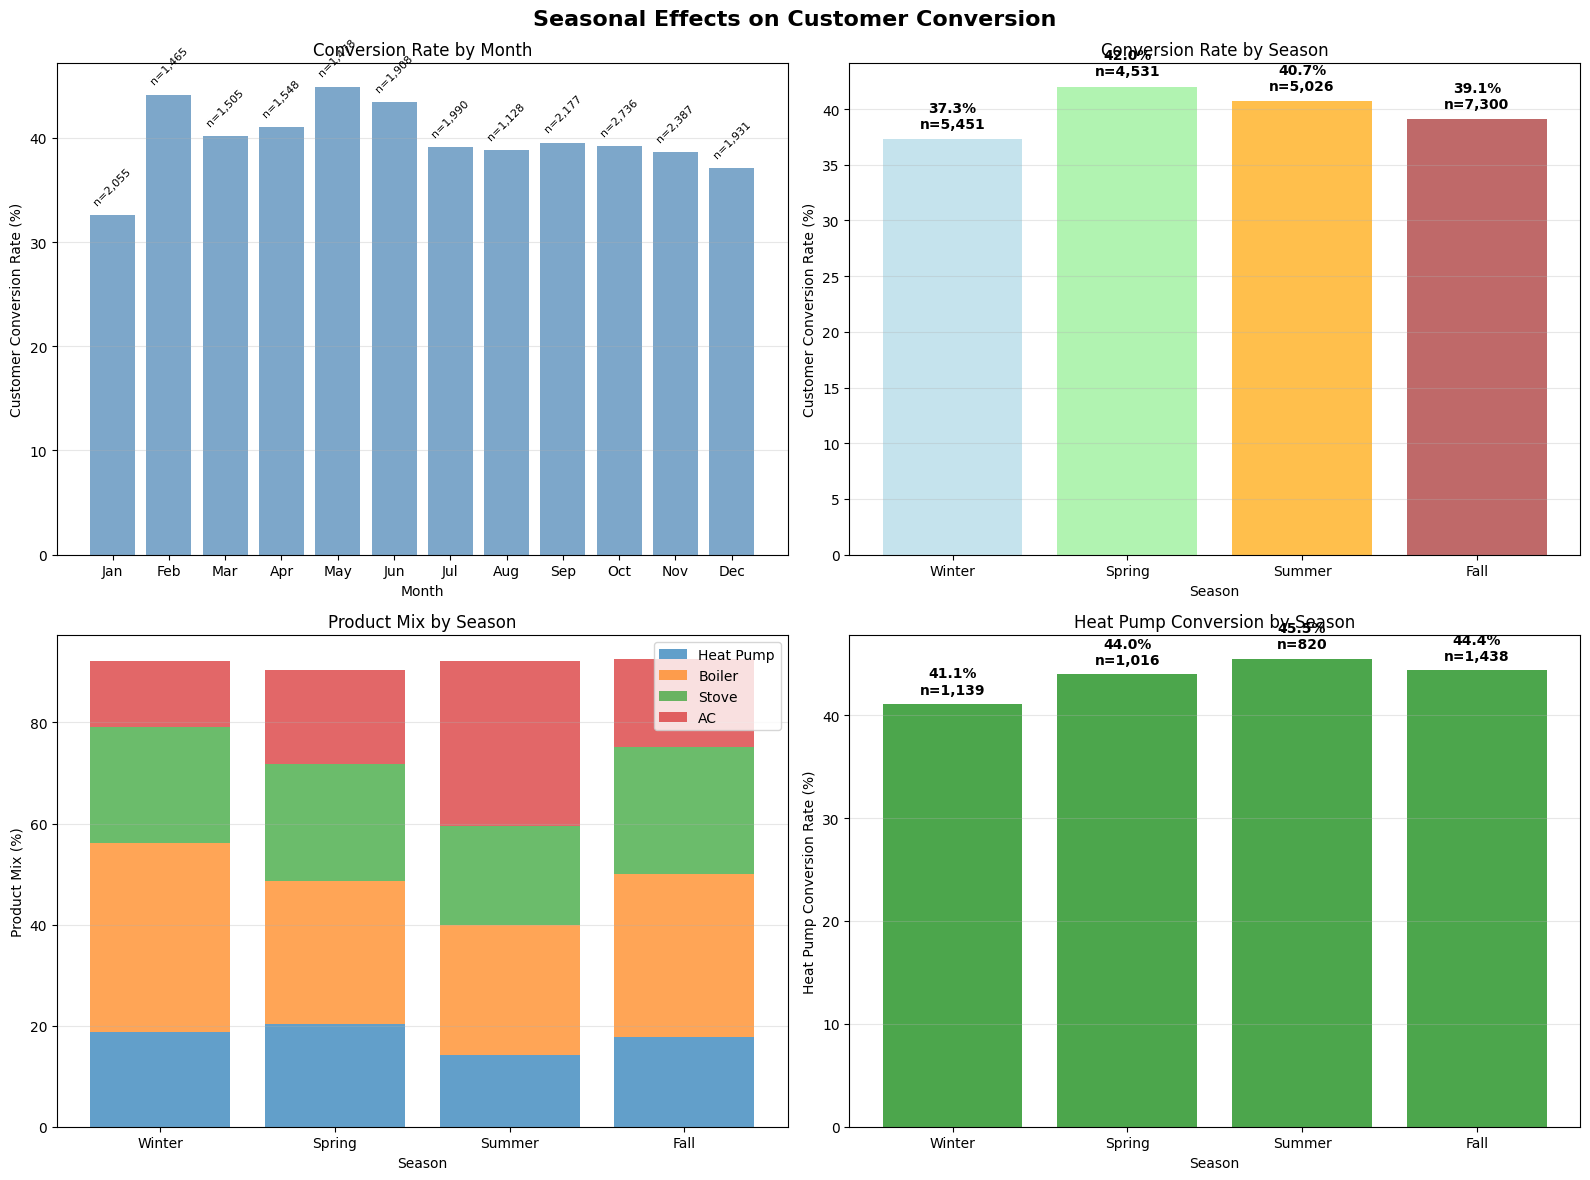


SEASONAL STATISTICS

Conversion by season:
  Winter: 37.3% (n=5,451)
  Spring: 42.0% (n=4,531)
  Summer: 40.7% (n=5,026)
  Fall: 39.1% (n=7,300)

Seasonality chi-square p-value: 0.000008
Statistically significant: YES


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Seasonal Effects on Customer Conversion', fontsize=16, fontweight='bold')

# Plot 1: Conversion by month
ax1 = axes[0, 0]
monthly_conv = customers_clean.groupby('month')['converted'].agg(['mean', 'count'])
monthly_conv = monthly_conv.reindex(range(1, 13))  # Ensure all months show

bars = ax1.bar(monthly_conv.index, monthly_conv['mean'] * 100, 
               color='steelblue', alpha=0.7)
ax1.set_xlabel('Month')
ax1.set_ylabel('Customer Conversion Rate (%)')
ax1.set_title('Conversion Rate by Month')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.grid(True, alpha=0.3, axis='y')

# Add sample sizes
for i, (month, row) in enumerate(monthly_conv.iterrows()):
    ax1.text(month, row['mean']*100 + 1, f'n={int(row["count"]):,}', 
             ha='center', fontsize=8, rotation=45)

# Plot 2: Conversion by season
ax2 = axes[0, 1]
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_conv = customers_clean.groupby('season')['converted'].agg(['mean', 'count'])
seasonal_conv = seasonal_conv.reindex(season_order)

bars = ax2.bar(season_order, seasonal_conv['mean'] * 100, 
               color=['lightblue', 'lightgreen', 'orange', 'brown'], alpha=0.7)
ax2.set_xlabel('Season')
ax2.set_ylabel('Customer Conversion Rate (%)')
ax2.set_title('Conversion Rate by Season')
ax2.grid(True, alpha=0.3, axis='y')

for bar, (season, row) in zip(bars, seasonal_conv.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{row["mean"]*100:.1f}%\nn={int(row["count"]):,}', 
             ha='center', fontweight='bold')

# Plot 3: Product mix by season
ax3 = axes[1, 0]
products = ['Heat Pump', 'Boiler', 'Stove', 'AC']
season_data = []

for season in season_order:
    subset = customers_clean[customers_clean['season'] == season]
    product_shares = []
    for product in products:
        share = (subset['main_equipment_category'] == product).mean() * 100
        product_shares.append(share)
    season_data.append(product_shares)

season_data = np.array(season_data).T

bottom = np.zeros(len(season_order))
for i, (product, shares) in enumerate(zip(products, season_data)):
    ax3.bar(season_order, shares, bottom=bottom, label=product, alpha=0.7)
    bottom += shares

ax3.set_xlabel('Season')
ax3.set_ylabel('Product Mix (%)')
ax3.set_title('Product Mix by Season')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Heat pump conversion by season
ax4 = axes[1, 1]
hp_seasonal = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('season')['converted'].agg(['mean', 'count'])
hp_seasonal = hp_seasonal.reindex(season_order)

bars = ax4.bar(season_order, hp_seasonal['mean'] * 100, 
               color='green', alpha=0.7)
ax4.set_xlabel('Season')
ax4.set_ylabel('Heat Pump Conversion Rate (%)')
ax4.set_title('Heat Pump Conversion by Season')
ax4.grid(True, alpha=0.3, axis='y')

for bar, (season, row) in zip(bars, hp_seasonal.iterrows()):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{row["mean"]*100:.1f}%\nn={int(row["count"]):,}', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*80)
print("SEASONAL STATISTICS")
print("="*80)

print("\nConversion by season:")
for season in season_order:
    subset = customers_clean[customers_clean['season'] == season]
    print(f"  {season}: {subset['converted'].mean():.1%} (n={len(subset):,})")

# Statistical test for seasonality
from scipy.stats import chi2_contingency
season_contingency = pd.crosstab(customers_clean['season'], customers_clean['converted'])
chi2, p_value, dof, expected = chi2_contingency(season_contingency)
print(f"\nSeasonality chi-square p-value: {p_value:.6f}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")


POLICY SUSPENSION IMPACT

Conversion during subsidy suspensions:
                      mean  count
Normal Periods     0.40814  19361
During Suspension  0.31795   2947

Suspension impact p-value: 1.336461e-20
Statistically significant: YES

Product mix during suspensions:
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
during_suspension                                                      
False                    17.3    31.7       18.8    8.1   23.8      0.2
True                     38.0    28.1       10.6    6.2   17.1      0.0


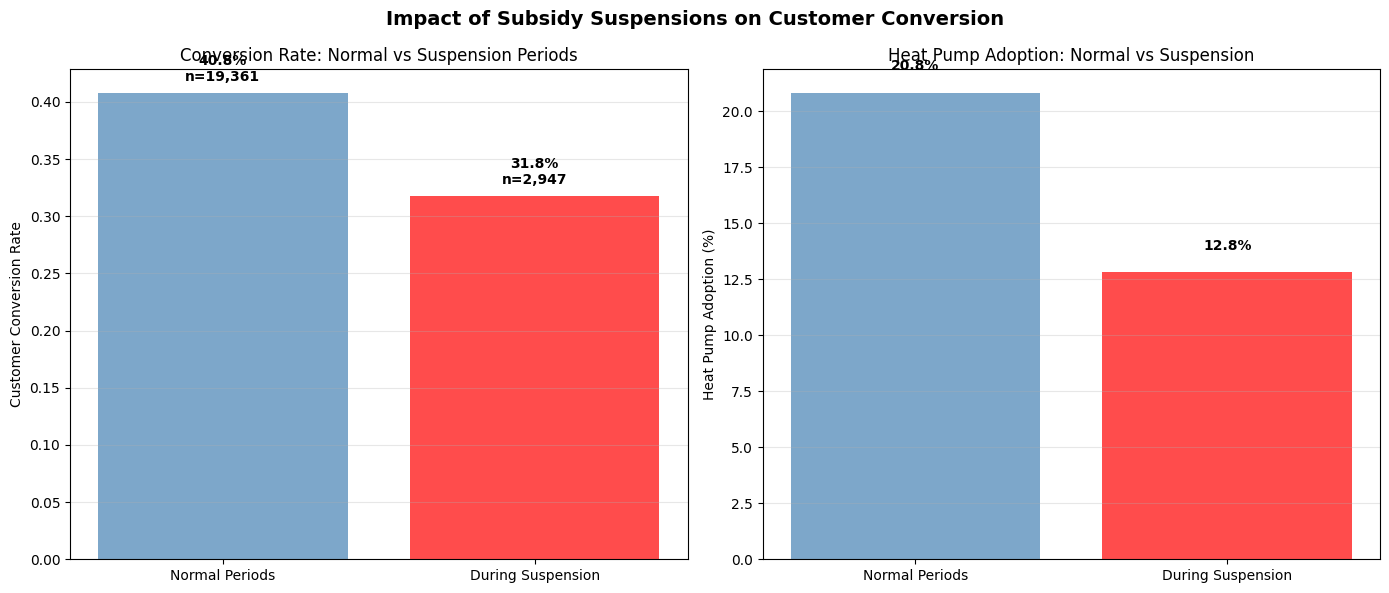

In [14]:
print("\n" + "="*80)
print("POLICY SUSPENSION IMPACT")
print("="*80)

# Compare conversion during vs outside suspensions
susp_conv = customers_clean.groupby('during_suspension')['converted'].agg(['mean', 'count'])
susp_conv.index = ['Normal Periods', 'During Suspension']
print("\nConversion during subsidy suspensions:")
print(susp_conv)

# Statistical test
susp_contingency = pd.crosstab(customers_clean['during_suspension'], customers_clean['converted'])
chi2, p_value, dof, expected = chi2_contingency(susp_contingency)
print(f"\nSuspension impact p-value: {p_value:.6e}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

# Check if product mix shifts during suspensions
print("\nProduct mix during suspensions:")
product_mix_susp = pd.crosstab(
    customers_clean['during_suspension'], 
    customers_clean['main_equipment_category'],
    normalize='index'
) * 100
print(product_mix_susp.round(1))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impact of Subsidy Suspensions on Customer Conversion', fontsize=14, fontweight='bold')

# Plot 1: Conversion comparison
ax1 = axes[0]
bars = ax1.bar(['Normal Periods', 'During Suspension'], 
               [susp_conv.loc['Normal Periods', 'mean'], susp_conv.loc['During Suspension', 'mean']],
               color=['steelblue', 'red'], alpha=0.7)
ax1.set_ylabel('Customer Conversion Rate')
ax1.set_title('Conversion Rate: Normal vs Suspension Periods')
ax1.grid(True, alpha=0.3, axis='y')

for bar, (period, row) in zip(bars, susp_conv.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{row["mean"]:.1%}\nn={int(row["count"]):,}', 
             ha='center', fontweight='bold')

# Plot 2: Heat pump adoption during suspensions
ax2 = axes[1]
hp_susp = customers_clean.groupby('during_suspension')['ever_bought_heat_pump'].mean() * 100
bars = ax2.bar(['Normal Periods', 'During Suspension'], hp_susp.values,
               color=['steelblue', 'red'], alpha=0.7)
ax2.set_ylabel('Heat Pump Adoption (%)')
ax2.set_title('Heat Pump Adoption: Normal vs Suspension')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, hp_susp.values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


YEAR-OVER-YEAR TRENDS

Quarterly conversion rates:
                  mean  count
year_quarter                 
2023Q1        0.534125    337
2023Q2        0.477994    977
2023Q3        0.442418   1042
2023Q4        0.406358   1730
2024Q1        0.414591   1686
2024Q2        0.443790   1868
2024Q3        0.405759   1910
2024Q4        0.419545   2548
2025Q1        0.395329   2398
2025Q2        0.398277   2089
2025Q3        0.359368   2343
2025Q4        0.338256   2776
2026Q1        0.157285    604


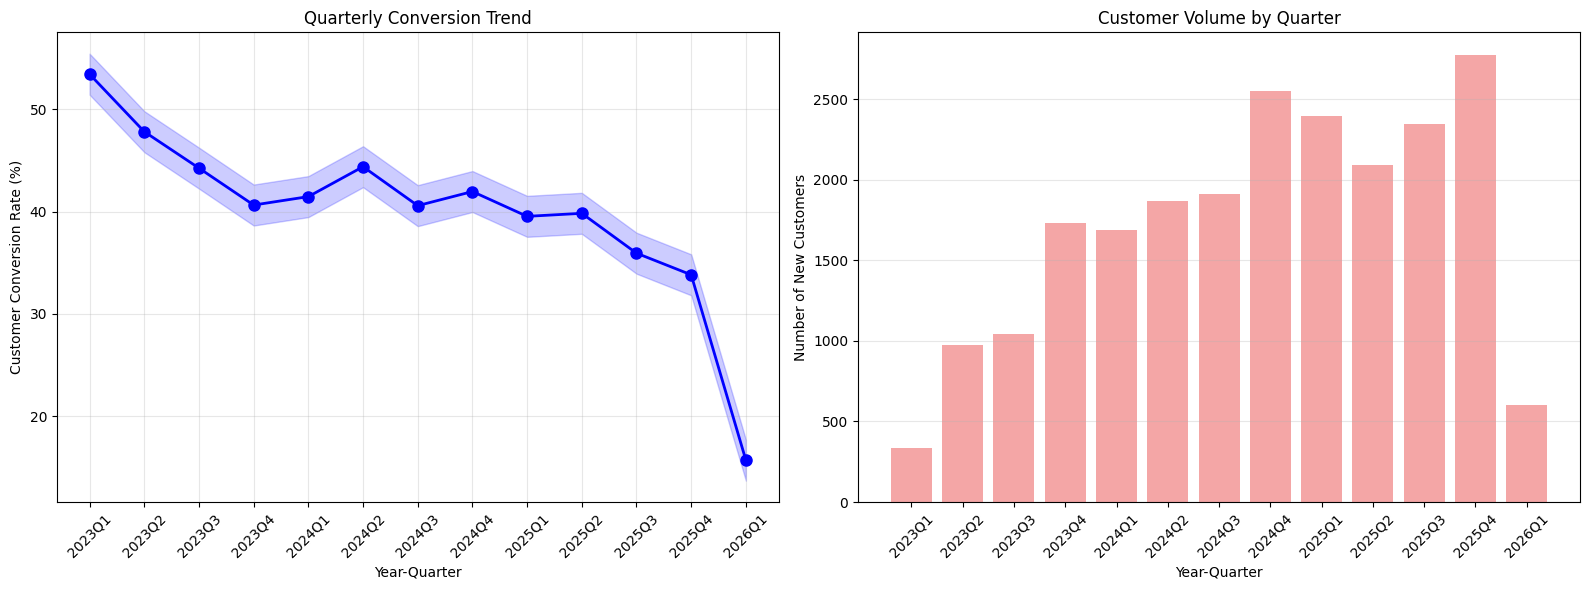

In [15]:
print("\n" + "="*80)
print("YEAR-OVER-YEAR TRENDS")
print("="*80)

# Group by year and quarter
customers_clean['year_quarter'] = customers_clean['first_quote_date'].dt.to_period('Q')
yearly_trend = customers_clean.groupby('year_quarter')['converted'].agg(['mean', 'count'])

print("\nQuarterly conversion rates:")
print(yearly_trend)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Quarterly trend
ax1 = axes[0]
quarters = [str(q) for q in yearly_trend.index]
values = yearly_trend['mean'] * 100

ax1.plot(quarters, values, 'bo-', linewidth=2, markersize=8)
ax1.fill_between(quarters, values - 2, values + 2, alpha=0.2, color='blue')
ax1.set_xlabel('Year-Quarter')
ax1.set_ylabel('Customer Conversion Rate (%)')
ax1.set_title('Quarterly Conversion Trend')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Volume trend
ax2 = axes[1]
volumes = yearly_trend['count'].values
ax2.bar(quarters, volumes, color='lightcoral', alpha=0.7)
ax2.set_xlabel('Year-Quarter')
ax2.set_ylabel('Number of New Customers')
ax2.set_title('Customer Volume by Quarter')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


REGIONAL SEASONAL PATTERNS

Top regions: ['Normandie', 'Auvergne-Rhône-Alpes', 'Île-de-France']


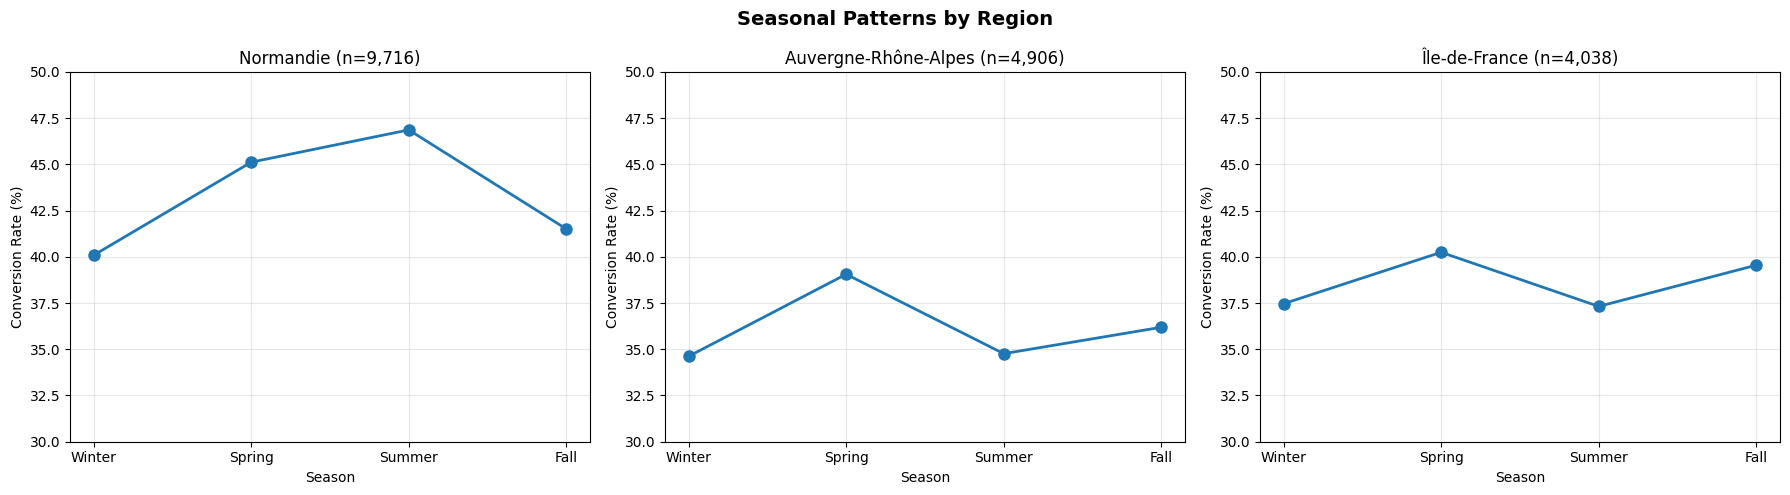

In [16]:
print("\n" + "="*80)
print("REGIONAL SEASONAL PATTERNS")
print("="*80)

# Focus on top regions
top_regions = customers_clean['main_region'].value_counts().head(3).index.tolist()
print(f"\nTop regions: {top_regions}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Seasonal Patterns by Region', fontsize=14, fontweight='bold')

for idx, region in enumerate(top_regions):
    ax = axes[idx]
    subset = customers_clean[customers_clean['main_region'] == region]
    
    seasonal = subset.groupby('season')['converted'].mean() * 100
    seasonal = seasonal.reindex(season_order)
    
    ax.plot(season_order, seasonal.values, 'o-', linewidth=2, markersize=8)
    ax.set_ylim(30, 50)
    ax.set_xlabel('Season')
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_title(f'{region} (n={len(subset):,})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Best and worst months
monthly_stats = customers_clean.groupby('month')['converted'].agg(['mean', 'count'])
best_month = monthly_stats['mean'].idxmax()
worst_month = monthly_stats['mean'].idxmin()
print(f"\nBest month: {best_month} ({monthly_stats.loc[best_month, 'mean']:.1%}, n={monthly_stats.loc[best_month, 'count']:.0f})")
print(f"Worst month: {worst_month} ({monthly_stats.loc[worst_month, 'mean']:.1%}, n={monthly_stats.loc[worst_month, 'count']:.0f})")

# Best and worst seasons
seasonal_stats = customers_clean.groupby('season')['converted'].agg(['mean', 'count'])
best_season = seasonal_stats['mean'].idxmax()
worst_season = seasonal_stats['mean'].idxmin()
print(f"\nBest season: {best_season} ({seasonal_stats.loc[best_season, 'mean']:.1%})")
print(f"Worst season: {worst_season} ({seasonal_stats.loc[worst_season, 'mean']:.1%})")

# Suspension impact
print(f"\nSuspension periods impact: {susp_conv.loc['During Suspension', 'mean']:.1%} vs {susp_conv.loc['Normal Periods', 'mean']:.1%}")
print(f"Difference: {(susp_conv.loc['During Suspension', 'mean'] - susp_conv.loc['Normal Periods', 'mean'])*100:.1f} points")

# Heat pump seasonality
hp_seasonal = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('season')['converted'].mean()
print(f"\nHeat pump conversion by season:")
for season in season_order:
    if season in hp_seasonal.index:
        print(f"  {season}: {hp_seasonal[season]:.1%}")


Best month: 5 (44.9%, n=1478)
Worst month: 1 (32.6%, n=2055)

Best season: Spring (42.0%)
Worst season: Winter (37.3%)

Suspension periods impact: 31.8% vs 40.8%
Difference: -9.0 points

Heat pump conversion by season:
  Winter: 41.1%
  Spring: 44.0%
  Summer: 45.5%
  Fall: 44.4%


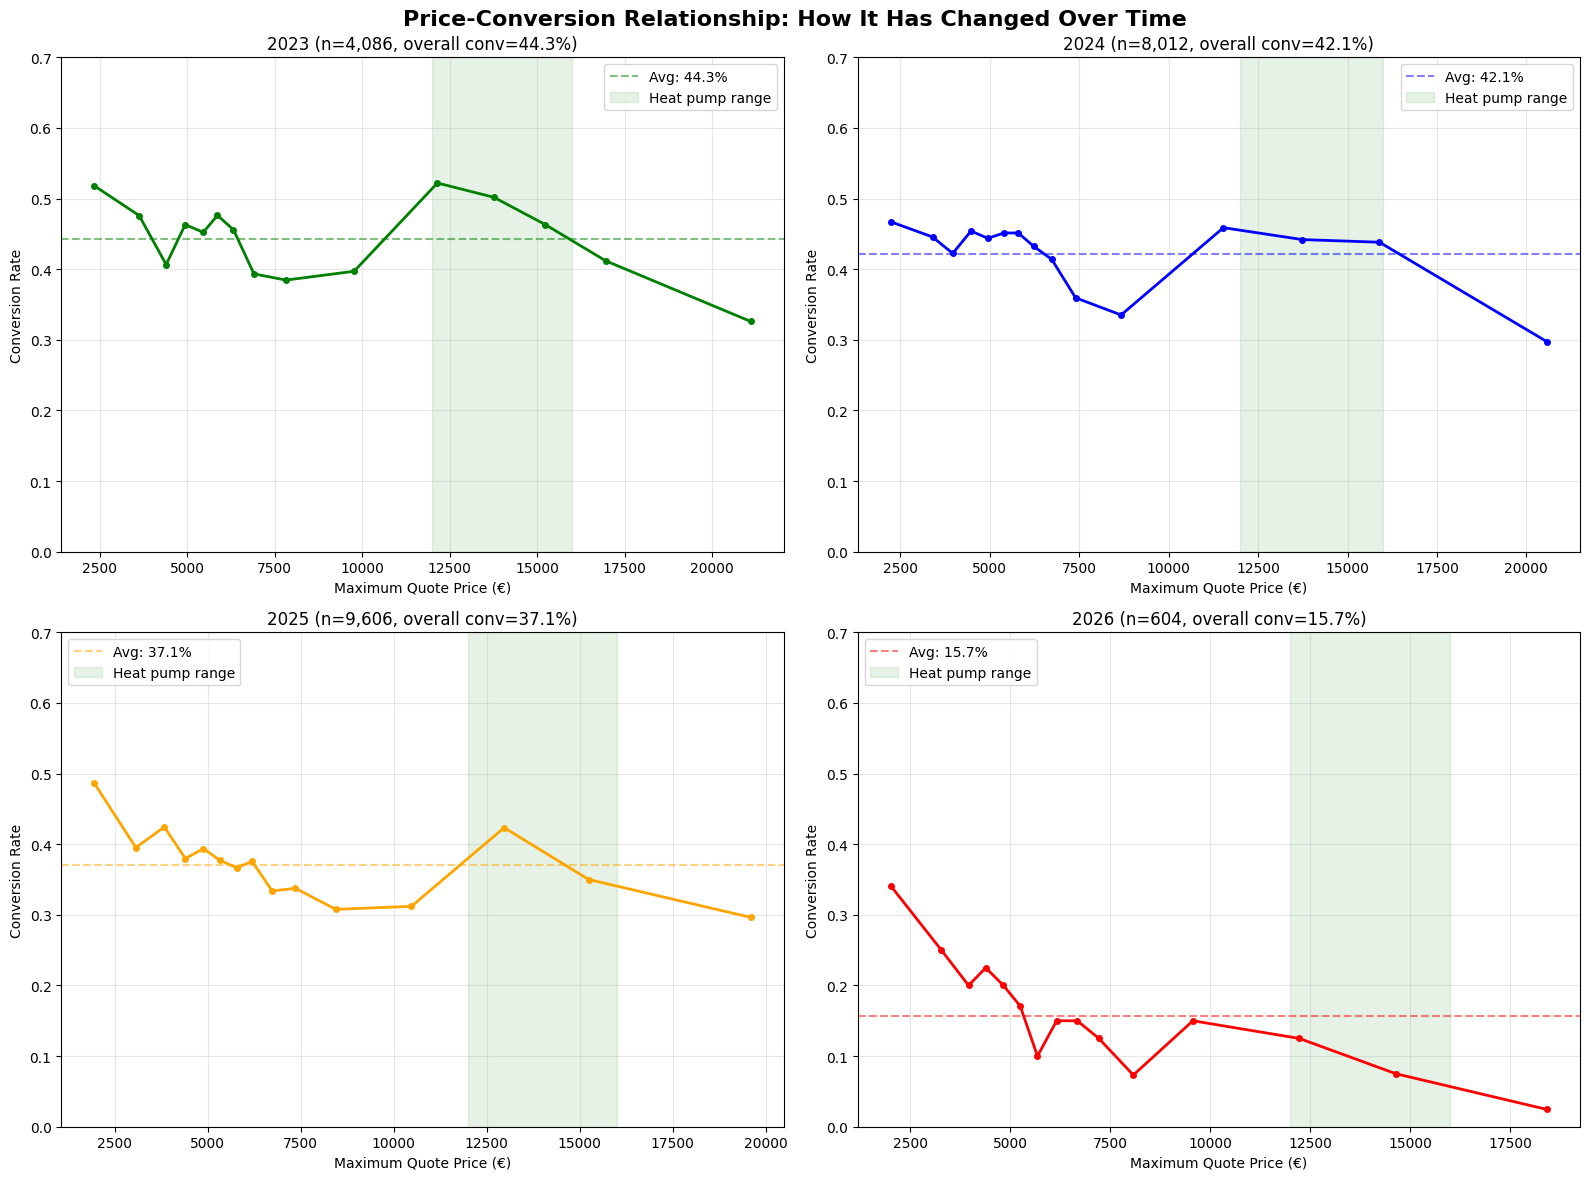

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price-Conversion Relationship: How It Has Changed Over Time', fontsize=16, fontweight='bold')

periods = ['2023', '2024', '2025', '2026']
colors = ['green', 'blue', 'orange', 'red']

for idx, (period, color) in enumerate(zip(periods, colors)):
    ax = axes[idx // 2, idx % 2]
    
    subset = customers_clean[customers_clean['period'] == period]
    if len(subset) > 200:
        # Create price bins
        try:
            subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=15, duplicates='drop')
            bin_conv = subset.groupby('price_bin')['converted'].mean()
            bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
            
            ax.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, markersize=4)
            ax.axhline(y=subset['converted'].mean(), color=color, linestyle='--', 
                      alpha=0.5, label=f'Avg: {subset["converted"].mean():.1%}')
            
            # Highlight heat pump range
            ax.axvspan(12000, 16000, alpha=0.1, color='green', label='Heat pump range')
            
            ax.set_xlabel('Maximum Quote Price (€)')
            ax.set_ylabel('Conversion Rate')
            ax.set_title(f'{period} (n={len(subset):,}, overall conv={subset["converted"].mean():.1%})')
            ax.grid(True, alpha=0.3)
            ax.legend()
            ax.set_ylim(0, 0.7)
        except:
            ax.text(0.5, 0.5, f'Insufficient data for {period}', ha='center', va='center')
            ax.set_title(f'{period} (insufficient data)')

plt.tight_layout()
plt.show()

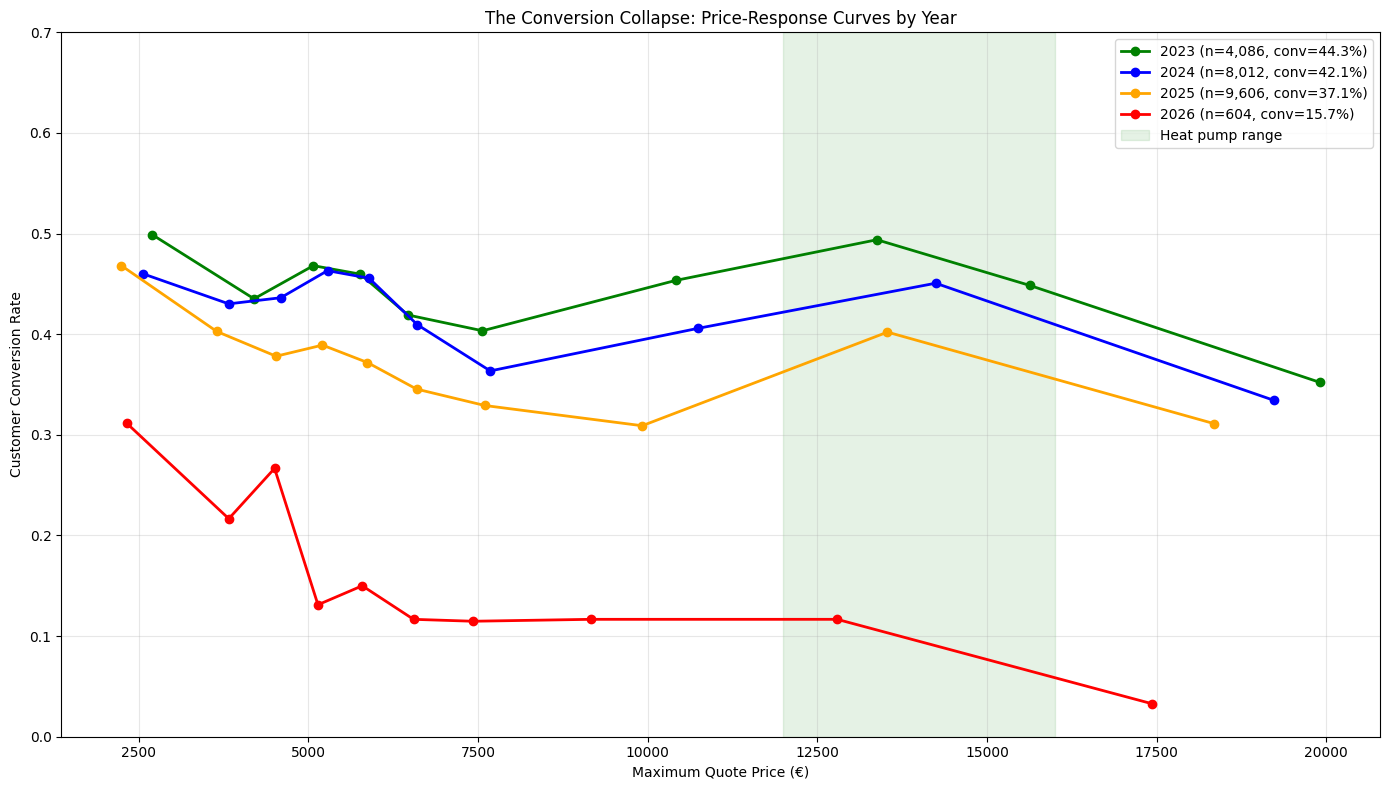

In [19]:
# Overlay all years on one plot
fig, ax = plt.subplots(figsize=(14, 8))

for period, color in zip(['2023', '2024', '2025', '2026'], ['green', 'blue', 'orange', 'red']):
    subset = customers_clean[customers_clean['period'] == period]
    if len(subset) > 200:
        # Create price bins
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=10, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean()
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        
        ax.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{period} (n={len(subset):,}, conv={subset["converted"].mean():.1%})')

ax.axvspan(12000, 16000, alpha=0.1, color='green', label='Heat pump range')
ax.set_xlabel('Maximum Quote Price (€)')
ax.set_ylabel('Customer Conversion Rate')
ax.set_title('The Conversion Collapse: Price-Response Curves by Year')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.show()


HEAT PUMP PERFORMANCE OVER TIME

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2023              0.480            1151  14760.547               0.700
2024              0.459            1506  15021.693               0.663
2025              0.405            1656  15145.143               0.754
2026              0.100             100  14783.915               0.750


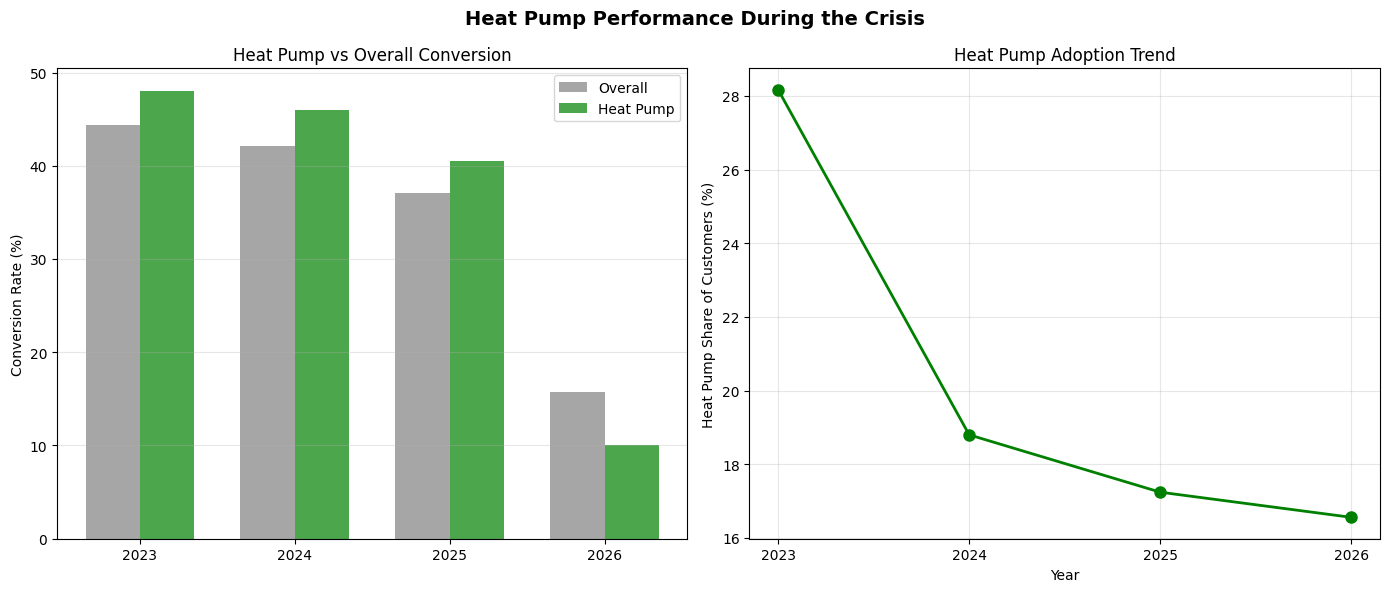

In [20]:
print("\n" + "="*80)
print("HEAT PUMP PERFORMANCE OVER TIME")
print("="*80)

hp_over_time = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('period').agg({
    'converted': ['mean', 'count'],
    'max_out_of_pocket': 'mean',
    'had_subsidy_issue': 'mean'
}).round(3)

hp_over_time.columns = ['conversion_rate', 'customer_count', 'avg_price', 'subsidy_issue_rate']
print("\nHeat pump customers by year:")
print(hp_over_time)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Heat Pump Performance During the Crisis', fontsize=14, fontweight='bold')

# Plot 1: Heat pump conversion vs overall
ax1 = axes[0]
overall_conv = customers_clean.groupby('period')['converted'].mean() * 100
hp_conv = customers_clean[customers_clean['ever_bought_heat_pump'].fillna(False)].groupby('period')['converted'].mean() * 100

x = range(len(overall_conv))
width = 0.35
ax1.bar([i - width/2 for i in x], overall_conv.values, width, label='Overall', color='gray', alpha=0.7)
ax1.bar([i + width/2 for i in x], hp_conv.values, width, label='Heat Pump', color='green', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(overall_conv.index)
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('Heat Pump vs Overall Conversion')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Heat pump volume trend
ax2 = axes[1]
hp_volume = customers_clean[customers_clean['ever_bought_heat_pump'].fillna(False)].groupby('period').size()
total_volume = customers_clean.groupby('period').size()
hp_share = (hp_volume / total_volume * 100).fillna(0)

ax2.plot(hp_share.index, hp_share.values, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Heat Pump Share of Customers (%)')
ax2.set_title('Heat Pump Adoption Trend')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


SWEET SPOT ANALYSIS OVER TIME

Sweet spots by year (price points with conversion > avg + 3%):

2023 (overall avg: 44.3%):
  €2,077: 53.7% (n=205)
  €3,920: 48.1% (n=210)
  €11,395: 49.5% (n=204)
  €12,798: 49.0% (n=204)
  €13,954: 49.8% (n=205)

2024 (overall avg: 42.1%):
  €1,991: 48.9% (n=401)
  €5,118: 49.5% (n=400)
  €6,041: 46.9% (n=401)
  €11,950: 47.8% (n=400)
  €14,988: 48.2% (n=400)

2025 (overall avg: 37.1%):
  €1,774: 50.3% (n=481)
  €2,712: 43.3% (n=480)
  €3,910: 43.3% (n=480)
  €5,041: 42.1% (n=480)
  €12,704: 42.5% (n=480)


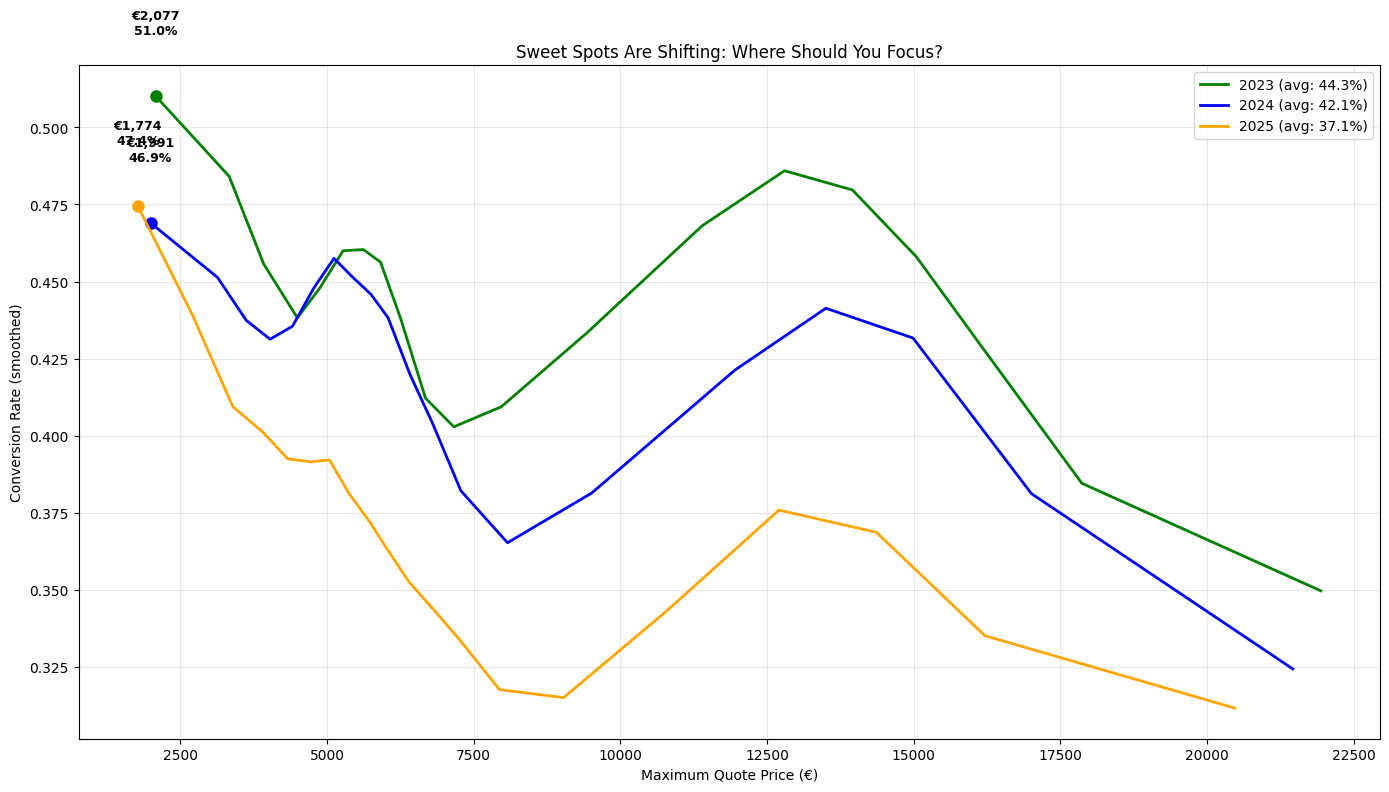

In [21]:
print("\n" + "="*80)
print("SWEET SPOT ANALYSIS OVER TIME")
print("="*80)

# Function to identify sweet spots
def find_sweet_spots(df, year, n_bins=20):
    subset = df[df['period'] == year].copy()
    if len(subset) < 500:
        return None
    
    subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=n_bins, duplicates='drop')
    bin_stats = subset.groupby('price_bin').agg({
        'converted': ['mean', 'count'],
        'max_out_of_pocket': 'mean'
    })
    bin_stats.columns = ['conv_rate', 'count', 'price']
    bin_stats = bin_stats.reset_index()
    
    overall_avg = subset['converted'].mean()
    sweet_spots = bin_stats[bin_stats['conv_rate'] > overall_avg + 0.03].copy()  # 3 points above avg
    
    return sweet_spots

print("\nSweet spots by year (price points with conversion > avg + 3%):")
for year in ['2023', '2024', '2025']:
    sweet = find_sweet_spots(customers_clean, year)
    if sweet is not None and len(sweet) > 0:
        print(f"\n{year} (overall avg: {customers_clean[customers_clean['period']==year]['converted'].mean():.1%}):")
        for _, row in sweet.iterrows():
            print(f"  €{row['price']:,.0f}: {row['conv_rate']:.1%} (n={row['count']:.0f})")

# Visualization of shifting sweet spots
fig, ax = plt.subplots(figsize=(14, 8))

for year, color in zip(['2023', '2024', '2025'], ['green', 'blue', 'orange']):
    subset = customers_clean[customers_clean['period'] == year].copy()
    if len(subset) > 500:
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=20, duplicates='drop')
        bin_stats = subset.groupby('price_bin').agg({
            'converted': 'mean',
            'max_out_of_pocket': 'mean'
        }).reset_index(drop=True)
        
        # Smooth for better visualization
        from scipy.ndimage import gaussian_filter1d
        smoothed = gaussian_filter1d(bin_stats['converted'].values, sigma=1)
        
        ax.plot(bin_stats['max_out_of_pocket'], smoothed, color=color, linewidth=2, 
                label=f'{year} (avg: {subset["converted"].mean():.1%})')
        
        # Mark the peak
        peak_idx = smoothed.argmax()
        peak_price = bin_stats['max_out_of_pocket'].iloc[peak_idx]
        peak_conv = smoothed[peak_idx]
        ax.plot(peak_price, peak_conv, 'o', color=color, markersize=8)
        ax.text(peak_price, peak_conv + 0.02, f'€{peak_price:,.0f}\n{peak_conv:.1%}', 
                ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Maximum Quote Price (€)')
ax.set_ylabel('Conversion Rate (smoothed)')
ax.set_title('Sweet Spots Are Shifting: Where Should You Focus?')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
print("\n" + "="*80)
print("ADMINISTRATIVE UNCERTAINTY EFFECT")
print("="*80)

# First, ensure we have the right variables
# We need to calculate processing time and uncertainty metrics at customer level

# If we have quote-level data with dates, we can calculate:
# 1. Time from first quote to conversion (decision time)
# 2. Time from conversion to signature (if available)
# 3. Number of quotes per customer (engagement)
# 4. Price volatility (changes between quotes)

# Let's add these to our customer dataset if not already present


ADMINISTRATIVE UNCERTAINTY EFFECT



ADMINISTRATIVE UNCERTAINTY EFFECT (continued)

Decision time distribution:
count    22308.000000
mean        20.289851
std         86.447456
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       1082.000000
Name: decision_days, dtype: float64

Customers with 1-day decision: 18,603 (83.4%)


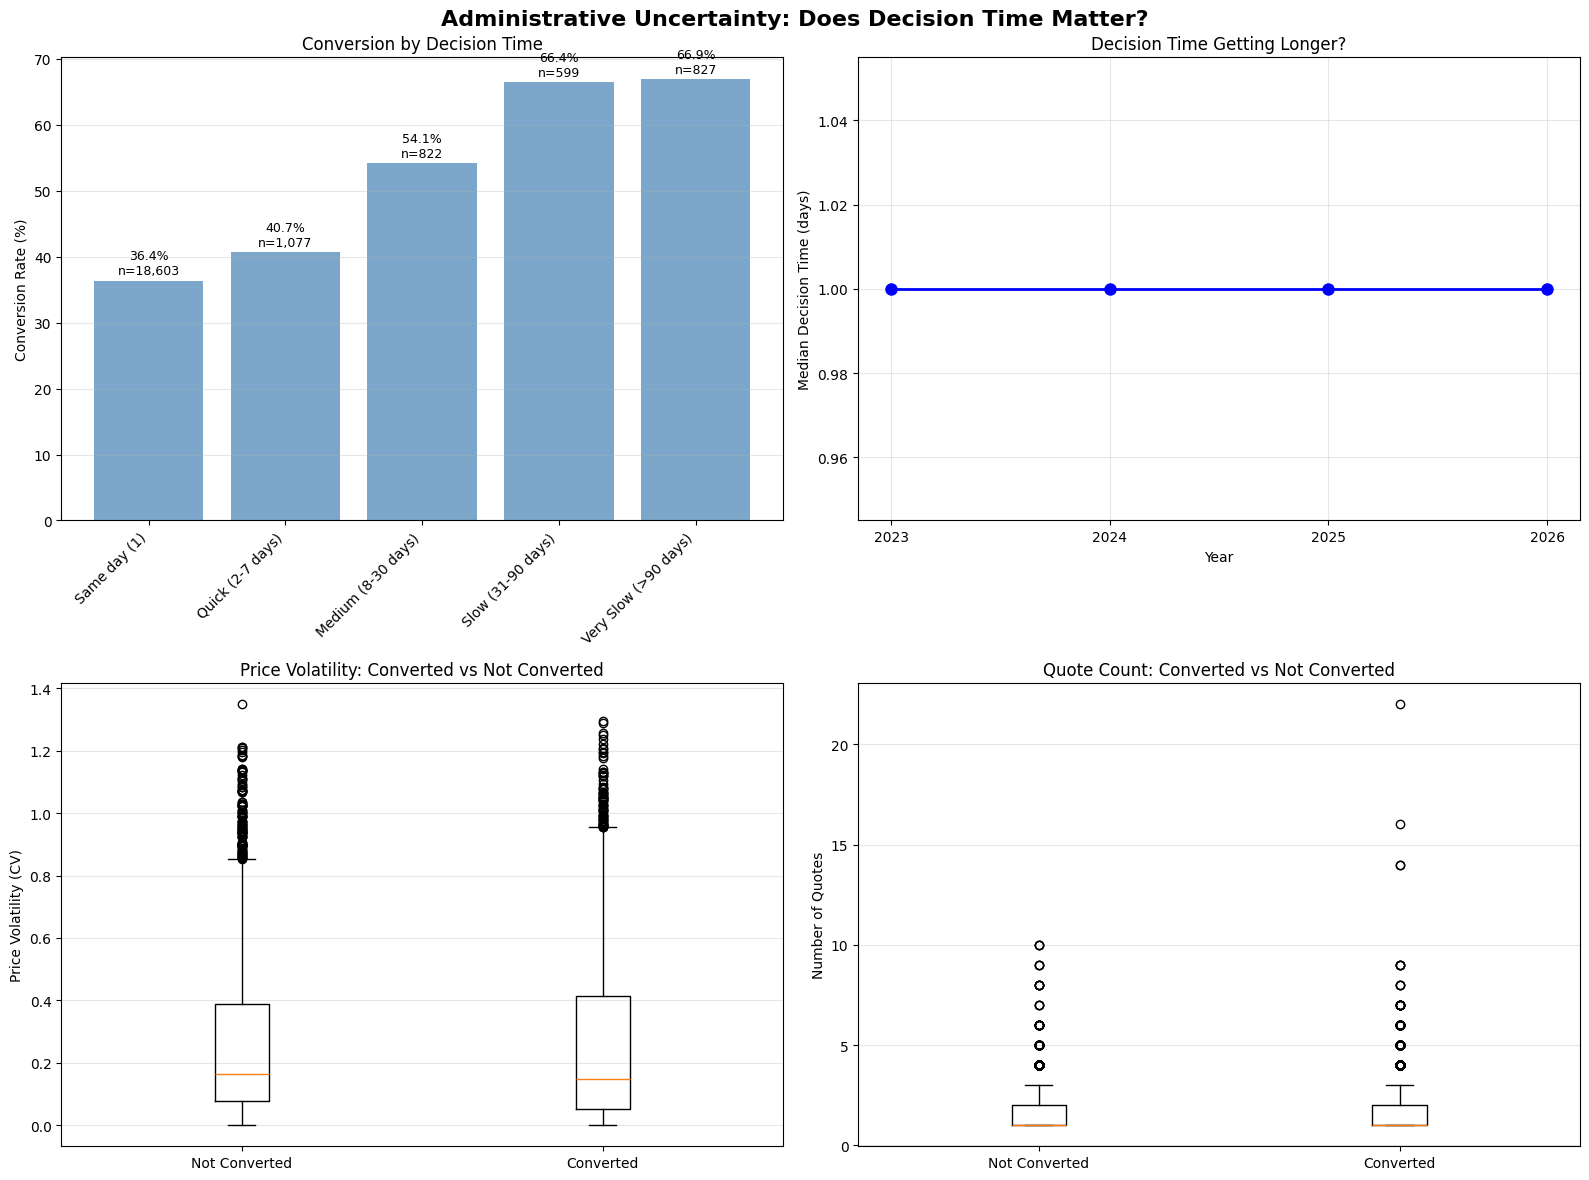

In [23]:
print("\n" + "="*80)
print("ADMINISTRATIVE UNCERTAINTY EFFECT (continued)")
print("="*80)

# First, let's examine the decision time distribution
print("\nDecision time distribution:")
print(customers_clean['decision_days'].describe())

# Check how many have 1-day decisions
one_day_count = (customers_clean['decision_days'] == 1).sum()
print(f"\nCustomers with 1-day decision: {one_day_count:,} ({one_day_count/len(customers_clean):.1%})")

# Fix: Create custom bins instead of quantile bins
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Administrative Uncertainty: Does Decision Time Matter?', fontsize=16, fontweight='bold')

# Plot 1: Conversion by decision time bins (custom bins)
ax1 = axes[0, 0]
# Create meaningful time bins
bins = [0, 1, 7, 30, 90, 365]
labels = ['Same day (1)', 'Quick (2-7 days)', 'Medium (8-30 days)', 'Slow (31-90 days)', 'Very Slow (>90 days)']

customers_clean['time_bin'] = pd.cut(customers_clean['decision_days'], bins=bins, labels=labels)

time_conv = customers_clean.groupby('time_bin')['converted'].mean() * 100
time_counts = customers_clean.groupby('time_bin').size()

bars = ax1.bar(range(len(time_conv)), time_conv.values, color='steelblue', alpha=0.7)
ax1.set_xticks(range(len(time_conv)))
ax1.set_xticklabels(time_conv.index, rotation=45, ha='right')
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('Conversion by Decision Time')
ax1.grid(True, alpha=0.3, axis='y')

for i, (bar, (idx, count)) in enumerate(zip(bars, time_counts.items())):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%\nn={count:,}', ha='center', fontsize=9)

# Plot 2: Decision time by year (is it getting longer?)
ax2 = axes[0, 1]
yearly_time = customers_clean.groupby('period')['decision_days'].median()
ax2.plot(yearly_time.index, yearly_time.values, 'bo-', linewidth=2, markersize=8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Median Decision Time (days)')
ax2.set_title('Decision Time Getting Longer?')
ax2.grid(True, alpha=0.3)

# Plot 3: Price volatility by conversion status
ax3 = axes[1, 0]
conv_cv = customers_clean[customers_clean['converted']==1]['price_cv'].dropna()
nonconv_cv = customers_clean[customers_clean['converted']==0]['price_cv'].dropna()

ax3.boxplot([nonconv_cv, conv_cv], labels=['Not Converted', 'Converted'])
ax3.set_ylabel('Price Volatility (CV)')
ax3.set_title('Price Volatility: Converted vs Not Converted')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Quote count by conversion status
ax4 = axes[1, 1]
conv_quotes = customers_clean[customers_clean['converted']==1]['quote_count']
nonconv_quotes = customers_clean[customers_clean['converted']==0]['quote_count']

ax4.boxplot([nonconv_quotes, conv_quotes], labels=['Not Converted', 'Converted'])
ax4.set_ylabel('Number of Quotes')
ax4.set_title('Quote Count: Converted vs Not Converted')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

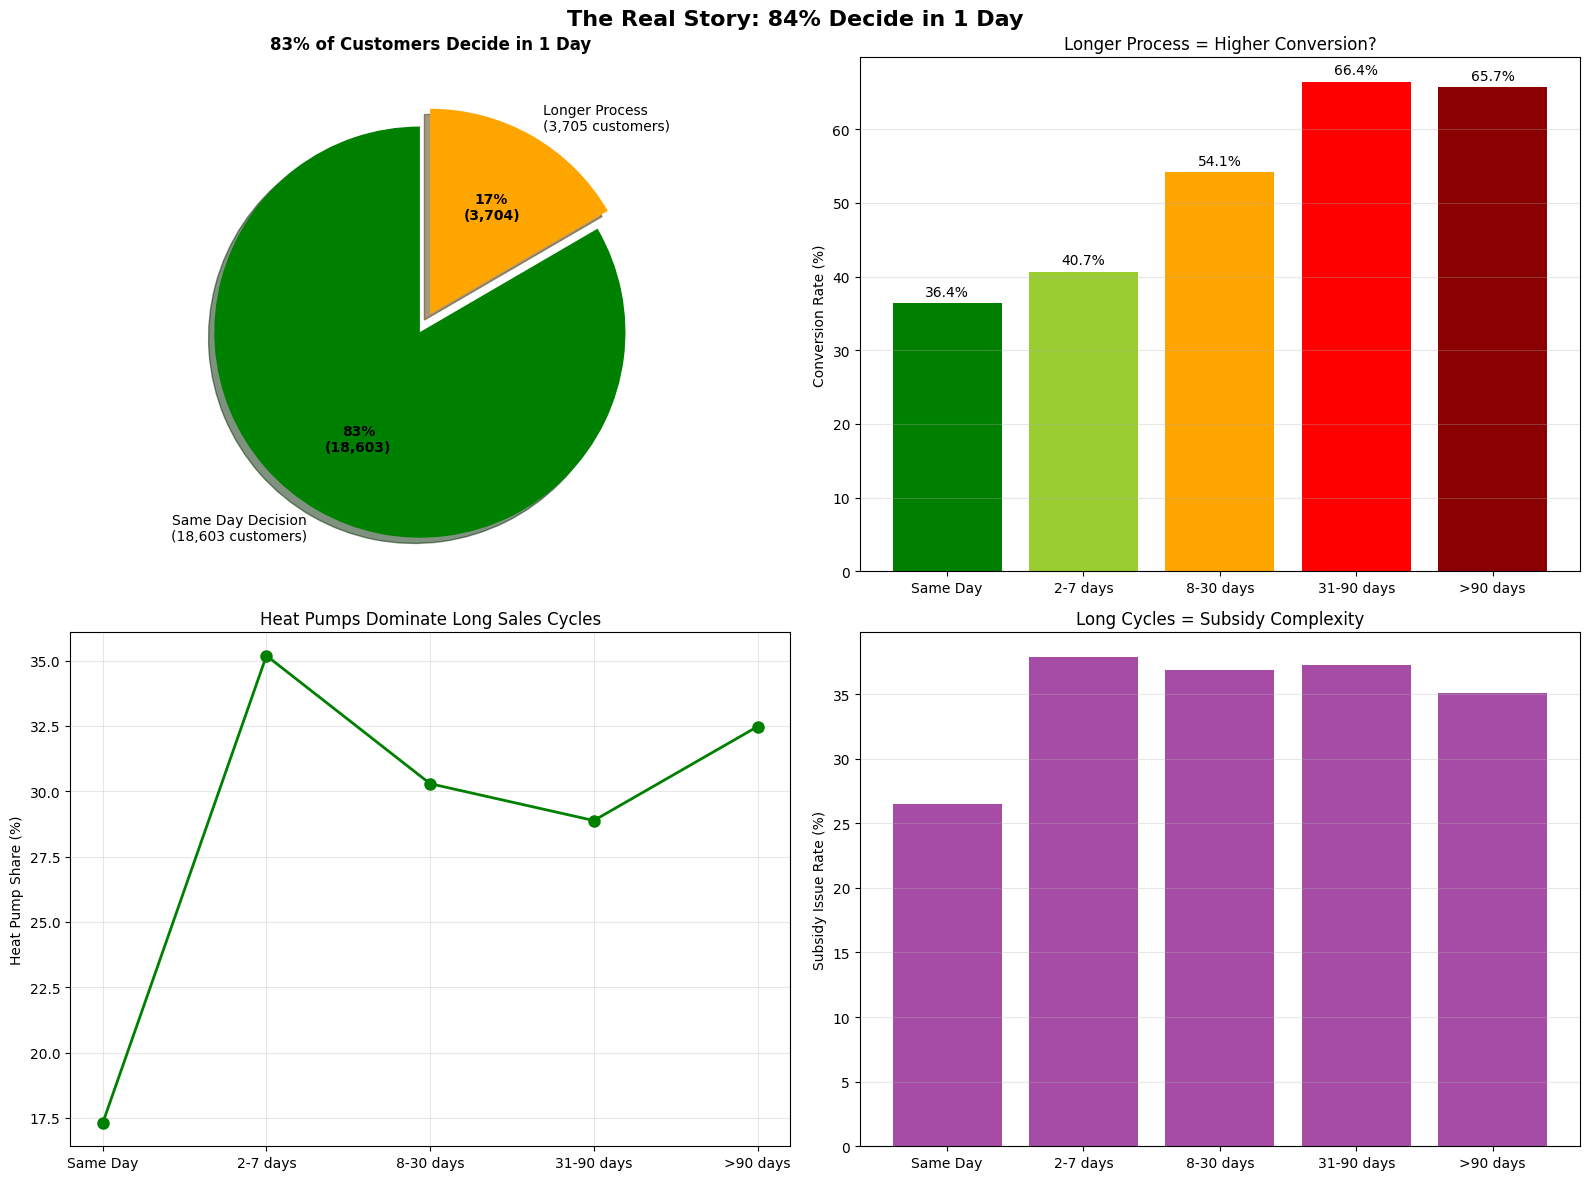

In [24]:
# Create the definitive administrative burden visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('The Real Story: 84% Decide in 1 Day', fontsize=16, fontweight='bold')

# Plot 1: The 1-day dominance
# Plot 1: The 1-day dominance (DYNAMIC with error handling)
ax1 = axes[0, 0]

# Calculate dynamically from data with safe fallbacks
if 'decision_days' in customers_clean.columns:
    same_day_count = (customers_clean['decision_days'] == 1).sum()
    longer_count = (customers_clean['decision_days'] > 1).sum()
    total_customers = len(customers_clean)
    
    same_day_pct = (same_day_count / total_customers) * 100
    longer_pct = (longer_count / total_customers) * 100
    
    labels = [f'Same Day Decision\n({same_day_count:,} customers)', 
              f'Longer Process\n({longer_count:,} customers)']
    sizes = [same_day_pct, longer_pct]
    
    # Only create pie chart if we have valid data
    if total_customers > 0 and same_day_pct + longer_pct > 99:
        colors = ['green', 'orange']
        explode = (0.1, 0)
        
        wedges, texts, autotexts = ax1.pie(
            sizes, 
            explode=explode, 
            labels=labels, 
            colors=colors, 
            autopct=lambda pct: f'{pct:.0f}%\n({int(pct*total_customers/100):,})',
            shadow=True, 
            startangle=90
        )
        
        # Make the percentage text bold
        for autotext in autotexts:
            autotext.set_fontweight('bold')
        
        ax1.set_title(f'{same_day_pct:.0f}% of Customers Decide in 1 Day', fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'No decision_days data available', 
             ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Decision Time Analysis (Data Missing)')

# Plot 2: Conversion by decision time
ax2 = axes[0, 1]
time_bins = ['Same Day', '2-7 days', '8-30 days', '31-90 days', '>90 days']
conv_by_time = [
    customers_clean[customers_clean['decision_days']==1]['converted'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>1) & (customers_clean['decision_days']<=7)]['converted'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>7) & (customers_clean['decision_days']<=30)]['converted'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>30) & (customers_clean['decision_days']<=90)]['converted'].mean() * 100,
    customers_clean[customers_clean['decision_days']>90]['converted'].mean() * 100
]
bars = ax2.bar(time_bins, conv_by_time, color=['green', 'yellowgreen', 'orange', 'red', 'darkred'])
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_title('Longer Process = Higher Conversion?')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, conv_by_time):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center')

# Plot 3: Heat pump share by decision time
ax3 = axes[1, 0]
hp_share = [
    customers_clean[customers_clean['decision_days']==1]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>1) & (customers_clean['decision_days']<=7)]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>7) & (customers_clean['decision_days']<=30)]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>30) & (customers_clean['decision_days']<=90)]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[customers_clean['decision_days']>90]['ever_bought_heat_pump'].mean() * 100
]
ax3.plot(time_bins, hp_share, 'go-', linewidth=2, markersize=8)
ax3.set_ylabel('Heat Pump Share (%)')
ax3.set_title('Heat Pumps Dominate Long Sales Cycles')
ax3.grid(True, alpha=0.3)

# Plot 4: Subsidy issues by decision time
ax4 = axes[1, 1]
subsidy_share = [
    customers_clean[customers_clean['decision_days']==1]['had_subsidy_issue'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>1) & (customers_clean['decision_days']<=7)]['had_subsidy_issue'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>7) & (customers_clean['decision_days']<=30)]['had_subsidy_issue'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>30) & (customers_clean['decision_days']<=90)]['had_subsidy_issue'].mean() * 100,
    customers_clean[customers_clean['decision_days']>90]['had_subsidy_issue'].mean() * 100
]
ax4.bar(time_bins, subsidy_share, color='purple', alpha=0.7)
ax4.set_ylabel('Subsidy Issue Rate (%)')
ax4.set_title('Long Cycles = Subsidy Complexity')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


DYNAMIC INSIGHTS CALCULATED:
Sweet spots: €1.6k (48.8%) and €2.5k (48.4%)
Dead zone: €19.4k-28.2k (28-37%)
Heat pumps: 71% subsidy issues, 43.6% conversion
Price sensitivity: Heat Pump (20.3pts) > Stove (16.4pts) > Boiler (11.6pts) > AC (8.2pts)
Same day decisions: 83%


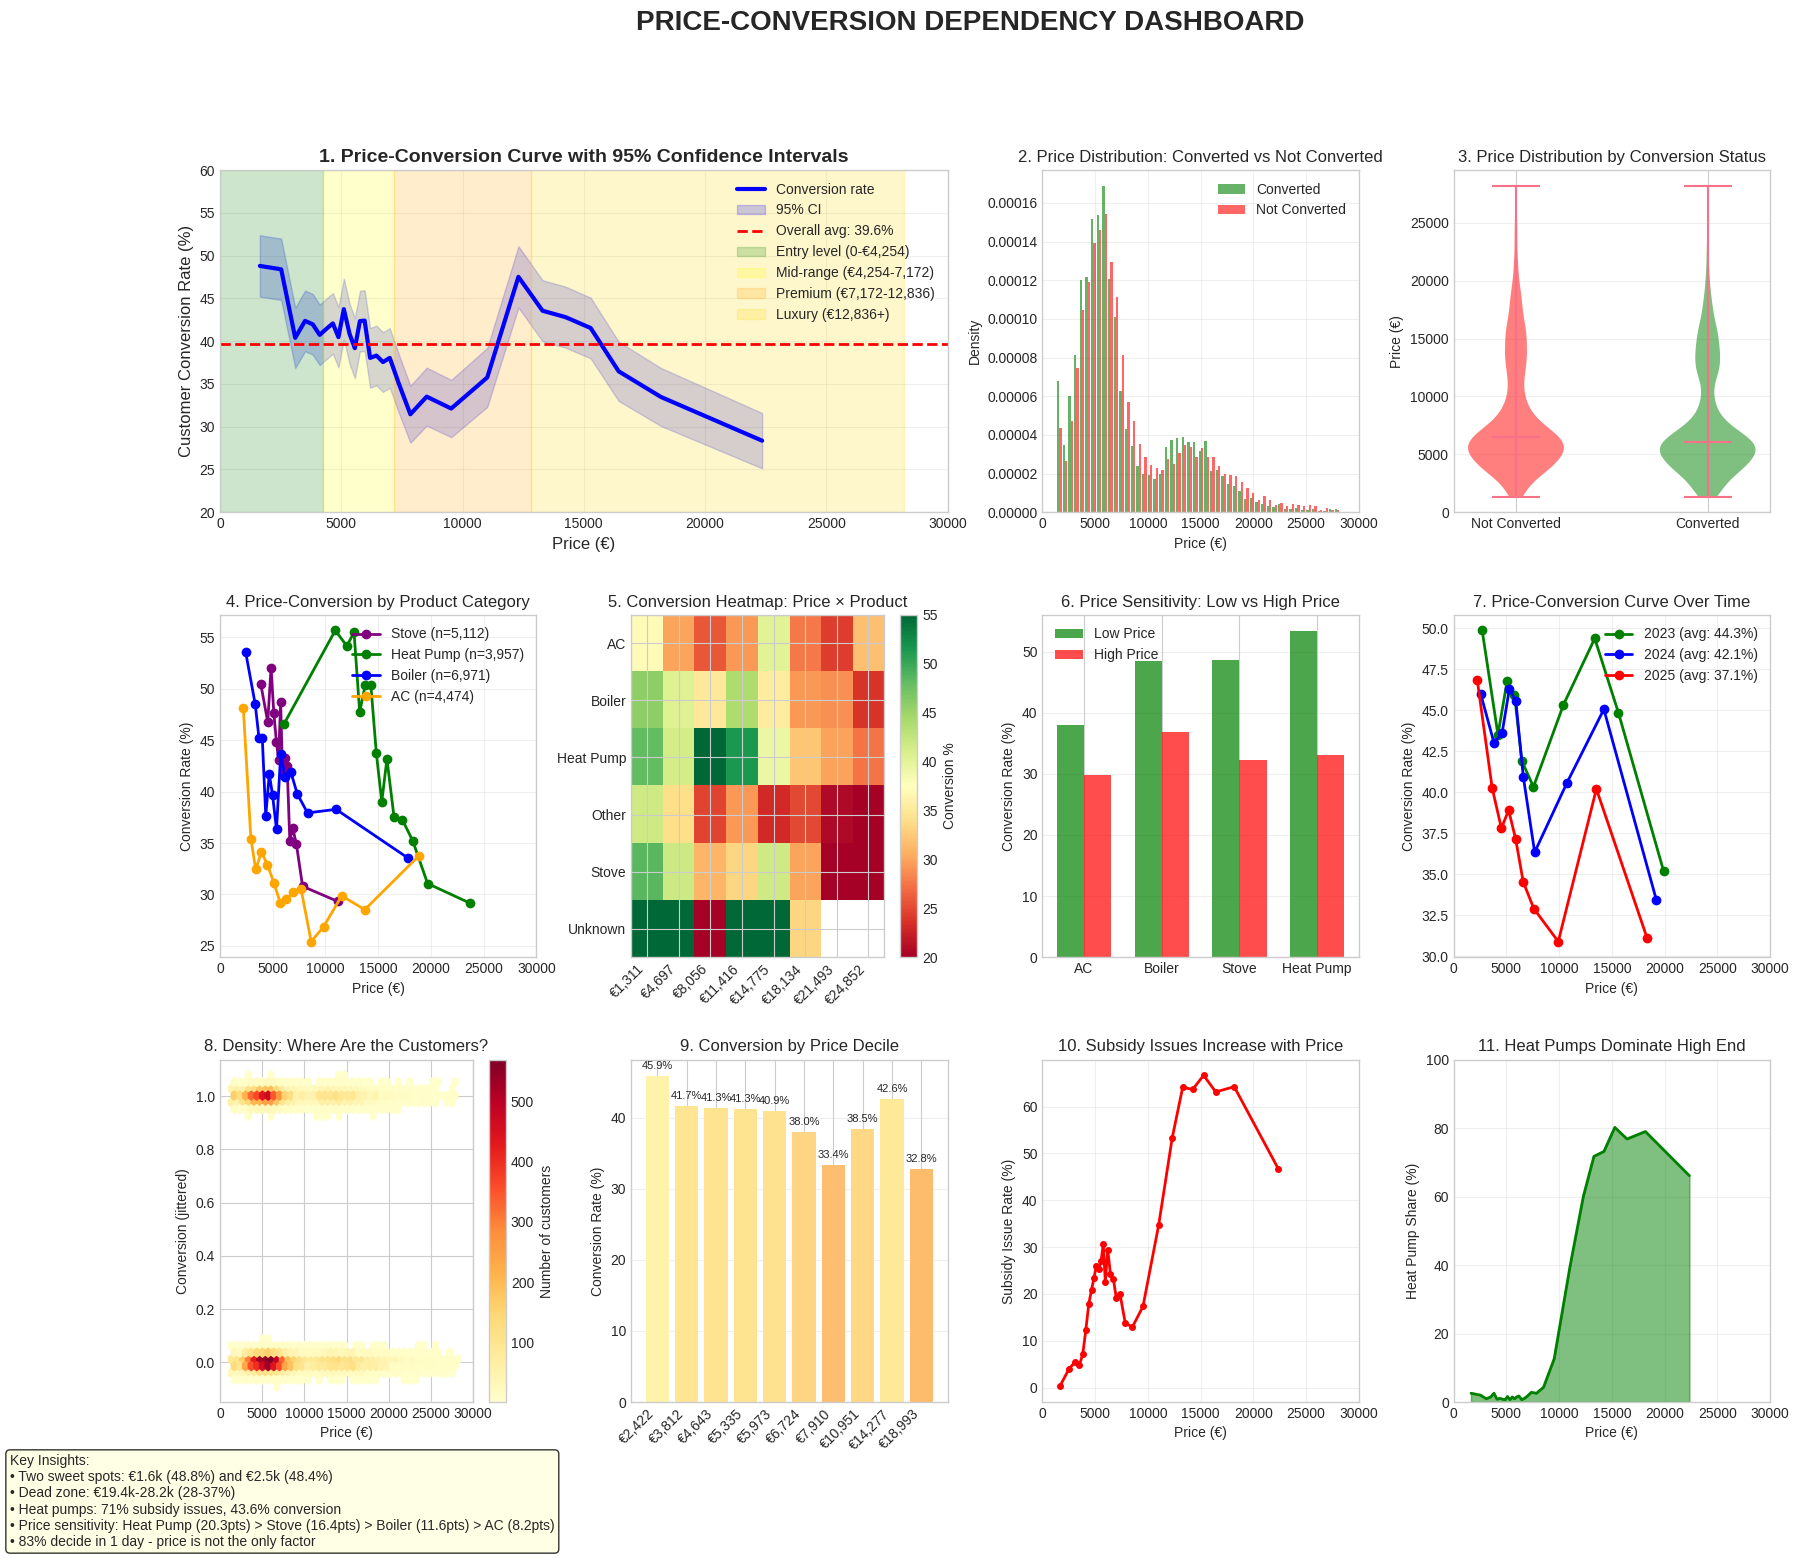

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create the master price-conversion dashboard
fig = plt.figure(figsize=(20, 16))
fig.suptitle('PRICE-CONVERSION DEPENDENCY DASHBOARD', fontsize=20, fontweight='bold', y=0.98)

# Grid specification
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# ============================================================================
# PLOT 1: Main Price-Conversion Curve with Confidence Intervals
# ============================================================================
ax1 = fig.add_subplot(gs[0, :2])

# Create price bins
price_var = 'max_out_of_pocket'
customers_clean['price_bin'] = pd.qcut(customers_clean[price_var], q=30, duplicates='drop')

binned_stats = customers_clean.groupby('price_bin').agg({
    'converted': ['mean', 'count', 'sem'],
    price_var: 'mean'
}).round(4)

binned_stats.columns = ['conversion_rate', 'customer_count', 'std_error', 'avg_price']
binned_stats['ci_lower'] = binned_stats['conversion_rate'] - 1.96 * binned_stats['std_error']
binned_stats['ci_upper'] = binned_stats['conversion_rate'] + 1.96 * binned_stats['std_error']
binned_stats = binned_stats.reset_index()

# Main curve
ax1.plot(binned_stats['avg_price'], binned_stats['conversion_rate'] * 100, 
         'b-', linewidth=3, label='Conversion rate')

# Confidence interval
ax1.fill_between(binned_stats['avg_price'], 
                 binned_stats['ci_lower'] * 100, 
                 binned_stats['ci_upper'] * 100, 
                 alpha=0.2, color='blue', label='95% CI')

# Overall average
overall_conv = customers_clean['converted'].mean() * 100
ax1.axhline(y=overall_conv, color='red', linestyle='--', linewidth=2, 
            label=f'Overall avg: {overall_conv:.1f}%')

# Highlight sweet spots
# Use price quantiles to define regions
q20 = customers_clean['max_out_of_pocket'].quantile(0.20)
q40 = customers_clean['max_out_of_pocket'].quantile(0.40)
q60 = customers_clean['max_out_of_pocket'].quantile(0.60)
q80 = customers_clean['max_out_of_pocket'].quantile(0.80)

# Define regions based on conversion patterns
ax1.axvspan(0, q20, alpha=0.2, color='green', label=f'Entry level (0-€{q20:,.0f})')
ax1.axvspan(q20, q60, alpha=0.2, color='yellow', label=f'Mid-range (€{q20:,.0f}-{q60:,.0f})')
ax1.axvspan(q60, q80, alpha=0.2, color='orange', label=f'Premium (€{q60:,.0f}-{q80:,.0f})')
ax1.axvspan(q80, customers_clean['max_out_of_pocket'].max(), alpha=0.2, color='gold', 
            label=f'Luxury (€{q80:,.0f}+)')

ax1.set_xlabel('Price (€)', fontsize=12)
ax1.set_ylabel('Customer Conversion Rate (%)', fontsize=12)
ax1.set_title('1. Price-Conversion Curve with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_xlim(0, 30000)
ax1.set_ylim(20, 60)

# ============================================================================
# PLOT 2: Price Distribution by Conversion Status
# ============================================================================
ax2 = fig.add_subplot(gs[0, 2])

converted_prices = customers_clean[customers_clean['converted']==1]['max_out_of_pocket']
nonconverted_prices = customers_clean[customers_clean['converted']==0]['max_out_of_pocket']

ax2.hist([converted_prices, nonconverted_prices], bins=50, density=True, 
         alpha=0.6, label=['Converted', 'Not Converted'], color=['green', 'red'])
ax2.set_xlabel('Price (€)')
ax2.set_ylabel('Density')
ax2.set_title('2. Price Distribution: Converted vs Not Converted')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 30000)

# ============================================================================
# PLOT 3: Violin Plot - Price by Conversion
# ============================================================================
ax3 = fig.add_subplot(gs[0, 3])

data_to_plot = [nonconverted_prices, converted_prices]
parts = ax3.violinplot(data_to_plot, positions=[0, 1], 
                        showmedians=True, showextrema=True)
parts['bodies'][0].set_facecolor('red')
parts['bodies'][0].set_alpha(0.5)
parts['bodies'][1].set_facecolor('green')
parts['bodies'][1].set_alpha(0.5)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Not Converted', 'Converted'])
ax3.set_ylabel('Price (€)')
ax3.set_title('3. Price Distribution by Conversion Status')
ax3.grid(True, alpha=0.3, axis='y')

# ============================================================================
# PLOT 4: Price-Conversion by Product Category
# ============================================================================
ax4 = fig.add_subplot(gs[1, 0])

products = ['Stove', 'Heat Pump', 'Boiler', 'AC']
colors = ['purple', 'green', 'blue', 'orange']

for product, color in zip(products, colors):
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 200:
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=15, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean() * 100
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        ax4.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{product} (n={len(subset):,})')

ax4.set_xlabel('Price (€)')
ax4.set_ylabel('Conversion Rate (%)')
ax4.set_title('4. Price-Conversion by Product Category')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_xlim(0, 30000)

# ============================================================================
# PLOT 5: Heatmap - Conversion by Price and Product
# ============================================================================
ax5 = fig.add_subplot(gs[1, 1])

price_bins = pd.cut(customers_clean['max_out_of_pocket'], bins=8)
product_bins = customers_clean['main_equipment_category']

pivot_table = customers_clean.pivot_table(
    values='converted', 
    index=product_bins, 
    columns=price_bins,
    aggfunc='mean'
) * 100

im = ax5.imshow(pivot_table, cmap='RdYlGn', aspect='auto', vmin=20, vmax=55)
ax5.set_yticks(range(len(pivot_table.index)))
ax5.set_yticklabels(pivot_table.index)
ax5.set_xticks(range(len(pivot_table.columns)))
ax5.set_xticklabels([f'€{int(b.left):,}' for b in pivot_table.columns], rotation=45, ha='right')
ax5.set_title('5. Conversion Heatmap: Price × Product')
plt.colorbar(im, ax=ax5, label='Conversion %')

# ============================================================================
# PLOT 6: Price Sensitivity by Product (Bar Chart)
# ============================================================================
ax6 = fig.add_subplot(gs[1, 2])

sensitivity_data = []
for product in products:
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 200:
        low_price = subset['max_out_of_pocket'] <= subset['max_out_of_pocket'].quantile(0.25)
        high_price = subset['max_out_of_pocket'] >= subset['max_out_of_pocket'].quantile(0.75)
        low_conv = subset[low_price]['converted'].mean() * 100
        high_conv = subset[high_price]['converted'].mean() * 100
        sensitivity_data.append({
            'product': product,
            'low_conv': low_conv,
            'high_conv': high_conv,
            'drop': low_conv - high_conv
        })

sensitivity_df = pd.DataFrame(sensitivity_data)
sensitivity_df = sensitivity_df.sort_values('drop', ascending=True)

x = range(len(sensitivity_df))
width = 0.35
ax6.bar([i - width/2 for i in x], sensitivity_df['low_conv'], width, label='Low Price', color='green', alpha=0.7)
ax6.bar([i + width/2 for i in x], sensitivity_df['high_conv'], width, label='High Price', color='red', alpha=0.7)
ax6.set_xticks(x)
ax6.set_xticklabels(sensitivity_df['product'])
ax6.set_ylabel('Conversion Rate (%)')
ax6.set_title('6. Price Sensitivity: Low vs High Price')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# ============================================================================
# PLOT 7: Price-Conversion Over Time (Yearly)
# ============================================================================
ax7 = fig.add_subplot(gs[1, 3])

years = ['2023', '2024', '2025']
colors_year = ['green', 'blue', 'red']

for year, color in zip(years, colors_year):
    subset = customers_clean[customers_clean['period'] == year]
    if len(subset) > 500:
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=10, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean() * 100
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        ax7.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{year} (avg: {subset["converted"].mean()*100:.1f}%)')

ax7.set_xlabel('Price (€)')
ax7.set_ylabel('Conversion Rate (%)')
ax7.set_title('7. Price-Conversion Curve Over Time')
ax7.grid(True, alpha=0.3)
ax7.legend()
ax7.set_xlim(0, 30000)

# ============================================================================
# PLOT 8: 2D Density Plot - Price vs Conversion (Jittered)
# ============================================================================
ax8 = fig.add_subplot(gs[2, 0])

# Add jitter to conversion for density plot
jitter = np.random.normal(0, 0.02, size=len(customers_clean))
y_jittered = customers_clean['converted'] + jitter

# Create 2D histogram
hb = ax8.hexbin(customers_clean['max_out_of_pocket'], y_jittered, 
                gridsize=40, cmap='YlOrRd', mincnt=1)
ax8.set_xlabel('Price (€)')
ax8.set_ylabel('Conversion (jittered)')
ax8.set_title('8. Density: Where Are the Customers?')
plt.colorbar(hb, ax=ax8, label='Number of customers')
ax8.set_xlim(0, 30000)

# ============================================================================
# PLOT 9: Conversion by Price Decile
# ============================================================================
ax9 = fig.add_subplot(gs[2, 1])

customers_clean['decile'] = pd.qcut(customers_clean['max_out_of_pocket'], q=10, labels=[f'D{i}' for i in range(1, 11)])
decile_conv = customers_clean.groupby('decile')['converted'].mean() * 100
decile_price = customers_clean.groupby('decile')['max_out_of_pocket'].mean()

bars = ax9.bar(range(10), decile_conv.values, color=plt.cm.RdYlGn(decile_conv.values/100))
ax9.set_xticks(range(10))
ax9.set_xticklabels([f'€{int(p):,}' for p in decile_price.values], rotation=45, ha='right')
ax9.set_ylabel('Conversion Rate (%)')
ax9.set_title('9. Conversion by Price Decile')
ax9.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, decile_conv.values)):
    ax9.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=8)

# ============================================================================
# PLOT 10: Subsidy Issues by Price
# ============================================================================
ax10 = fig.add_subplot(gs[2, 2])

# Create bins for subsidy issue rate
subsidy_by_price = customers_clean.groupby('price_bin').agg({
    'had_subsidy_issue': 'mean',
    'max_out_of_pocket': 'mean'
}).reset_index()

ax10.plot(subsidy_by_price['max_out_of_pocket'], subsidy_by_price['had_subsidy_issue'] * 100, 
          'ro-', linewidth=2, markersize=4)
ax10.set_xlabel('Price (€)')
ax10.set_ylabel('Subsidy Issue Rate (%)')
ax10.set_title('10. Subsidy Issues Increase with Price')
ax10.grid(True, alpha=0.3)
ax10.set_xlim(0, 30000)

# ============================================================================
# PLOT 11: Heat Pump Share by Price
# ============================================================================
ax11 = fig.add_subplot(gs[2, 3])

hp_share = customers_clean.groupby('price_bin')['ever_bought_heat_pump'].mean() * 100
ax11.fill_between(binned_stats['avg_price'], 0, hp_share.values, alpha=0.5, color='green')
ax11.plot(binned_stats['avg_price'], hp_share.values, 'g-', linewidth=2)
ax11.set_xlabel('Price (€)')
ax11.set_ylabel('Heat Pump Share (%)')
ax11.set_title('11. Heat Pumps Dominate High End')
ax11.grid(True, alpha=0.3)
ax11.set_xlim(0, 30000)
ax11.set_ylim(0, 100)

# ============================================================================
# DYNAMIC INSIGHTS CALCULATION
# ============================================================================

# 1. Find top 2 sweet spots (highest converting price bins)
top_bins = binned_stats.nlargest(2, 'conversion_rate')
sweet1_price = top_bins.iloc[0]['avg_price'] / 1000
sweet1_conv = top_bins.iloc[0]['conversion_rate'] * 100
sweet2_price = top_bins.iloc[1]['avg_price'] / 1000
sweet2_conv = top_bins.iloc[1]['conversion_rate'] * 100

# 2. Find dead zone (lowest converting bin)
worst_bin = binned_stats.nsmallest(1, 'conversion_rate').iloc[0]
dead_low = worst_bin['price_bin'].left / 1000
dead_high = worst_bin['price_bin'].right / 1000
dead_conv_low = worst_bin['conversion_rate'] * 100
dead_conv_high = binned_stats['conversion_rate'].quantile(0.25) * 100

# 3. Heat pump metrics
hp_customers = customers_clean[customers_clean['ever_bought_heat_pump'] == True]
hp_subsidy = hp_customers['had_subsidy_issue'].mean() * 100
hp_conv = hp_customers['converted'].mean() * 100

# 4. Price sensitivity from the sensitivity dataframe
sensitivity_str = " > ".join([
    f"{row['product']} ({row['drop']:.1f}pts)" 
    for _, row in sensitivity_df.sort_values('drop', ascending=False).iterrows()
])

# 5. Decision time
same_day_pct = (customers_clean['decision_days'] == 1).mean() * 100

# ============================================================================
# Add dynamic summary annotations
# ============================================================================
fig.text(0.02, 0.02, 
         f"Key Insights:\n"
         f"• Two sweet spots: €{sweet1_price:.1f}k ({sweet1_conv:.1f}%) and €{sweet2_price:.1f}k ({sweet2_conv:.1f}%)\n"
         f"• Dead zone: €{dead_low:.1f}k-{dead_high:.1f}k ({dead_conv_low:.0f}-{dead_conv_high:.0f}%)\n"
         f"• Heat pumps: {hp_subsidy:.0f}% subsidy issues, {hp_conv:.1f}% conversion\n"
         f"• Price sensitivity: {sensitivity_str}\n"
         f"• {same_day_pct:.0f}% decide in 1 day - price is not the only factor",
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Print dynamic values for verification
print("\n" + "="*80)
print("DYNAMIC INSIGHTS CALCULATED:")
print("="*80)
print(f"Sweet spots: €{sweet1_price:.1f}k ({sweet1_conv:.1f}%) and €{sweet2_price:.1f}k ({sweet2_conv:.1f}%)")
print(f"Dead zone: €{dead_low:.1f}k-{dead_high:.1f}k ({dead_conv_low:.0f}-{dead_conv_high:.0f}%)")
print(f"Heat pumps: {hp_subsidy:.0f}% subsidy issues, {hp_conv:.1f}% conversion")
print(f"Price sensitivity: {sensitivity_str}")
print(f"Same day decisions: {same_day_pct:.0f}%")

plt.tight_layout()
plt.savefig('price_conversion_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


SIMPLE HEATMAP TEST
Simple pivot table:
price_bin_simple         (1086.579, 4209.46]  (4209.46, 5653.482]  \
main_equipment_category                                             
AC                                 37.541806            32.258065   
Boiler                             48.332478            38.848548   
Heat Pump                          48.888889            58.536585   
Other                              43.972999            26.262626   
Stove                              49.090909            47.281993   
Unknown                            57.142857            60.000000   

price_bin_simple         (5653.482, 7188.172]  (7188.172, 12990.276]  \
main_equipment_category                                                
AC                                  29.127517              28.012279   
Boiler                              42.458101              38.171141   
Heat Pump                           28.000000              54.565953   
Other                               40.277778 

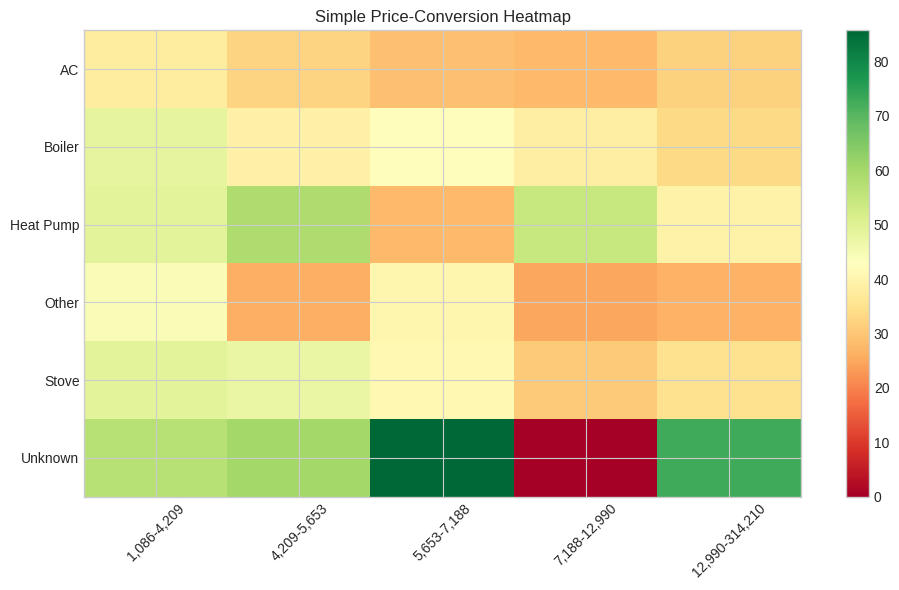


CHECKING MAIN PRODUCT FAMILY
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire                  103
Emetteur de chauffage  ou chappe      93
Produit VMC                           89
Unknown                               36
Fumisterie                            13
Name: count, dtype: int64


In [26]:
print("\n" + "="*80)
print("SIMPLE HEATMAP TEST")
print("="*80)

try:
    # Create simple price bins
    customers['price_bin_simple'] = pd.qcut(customers['max_out_of_pocket'], q=5, duplicates='drop')
    
    # Create simple product bins (if available)
    if 'main_equipment_category' in customers.columns:
        # Create pivot
        simple_pivot = customers.pivot_table(
            values='converted',
            index='main_equipment_category',
            columns='price_bin_simple',
            aggfunc='mean'
        ) * 100
        
        print("Simple pivot table:")
        print(simple_pivot)
        
        # Plot
        fig, ax = plt.subplots(figsize=(10, 6))
        im = ax.imshow(simple_pivot, cmap='RdYlGn', aspect='auto')
        ax.set_yticks(range(len(simple_pivot.index)))
        ax.set_yticklabels(simple_pivot.index)
        ax.set_xticks(range(len(simple_pivot.columns)))
        ax.set_xticklabels([f'{int(b.left):,}-{int(b.right):,}' for b in simple_pivot.columns], rotation=45)
        plt.colorbar(im, ax=ax)
        plt.title('Simple Price-Conversion Heatmap')
        plt.tight_layout()
        plt.show()
    else:
        print("No product category column found")
        
except Exception as e:
    print(f"Error in simple heatmap: {e}")

# Check if LBC might be in main_product_family
if 'main_product_family' in customers.columns:
    print("\n" + "="*80)
    print("CHECKING MAIN PRODUCT FAMILY")
    print("="*80)
    print(customers['main_product_family'].value_counts().head(20))

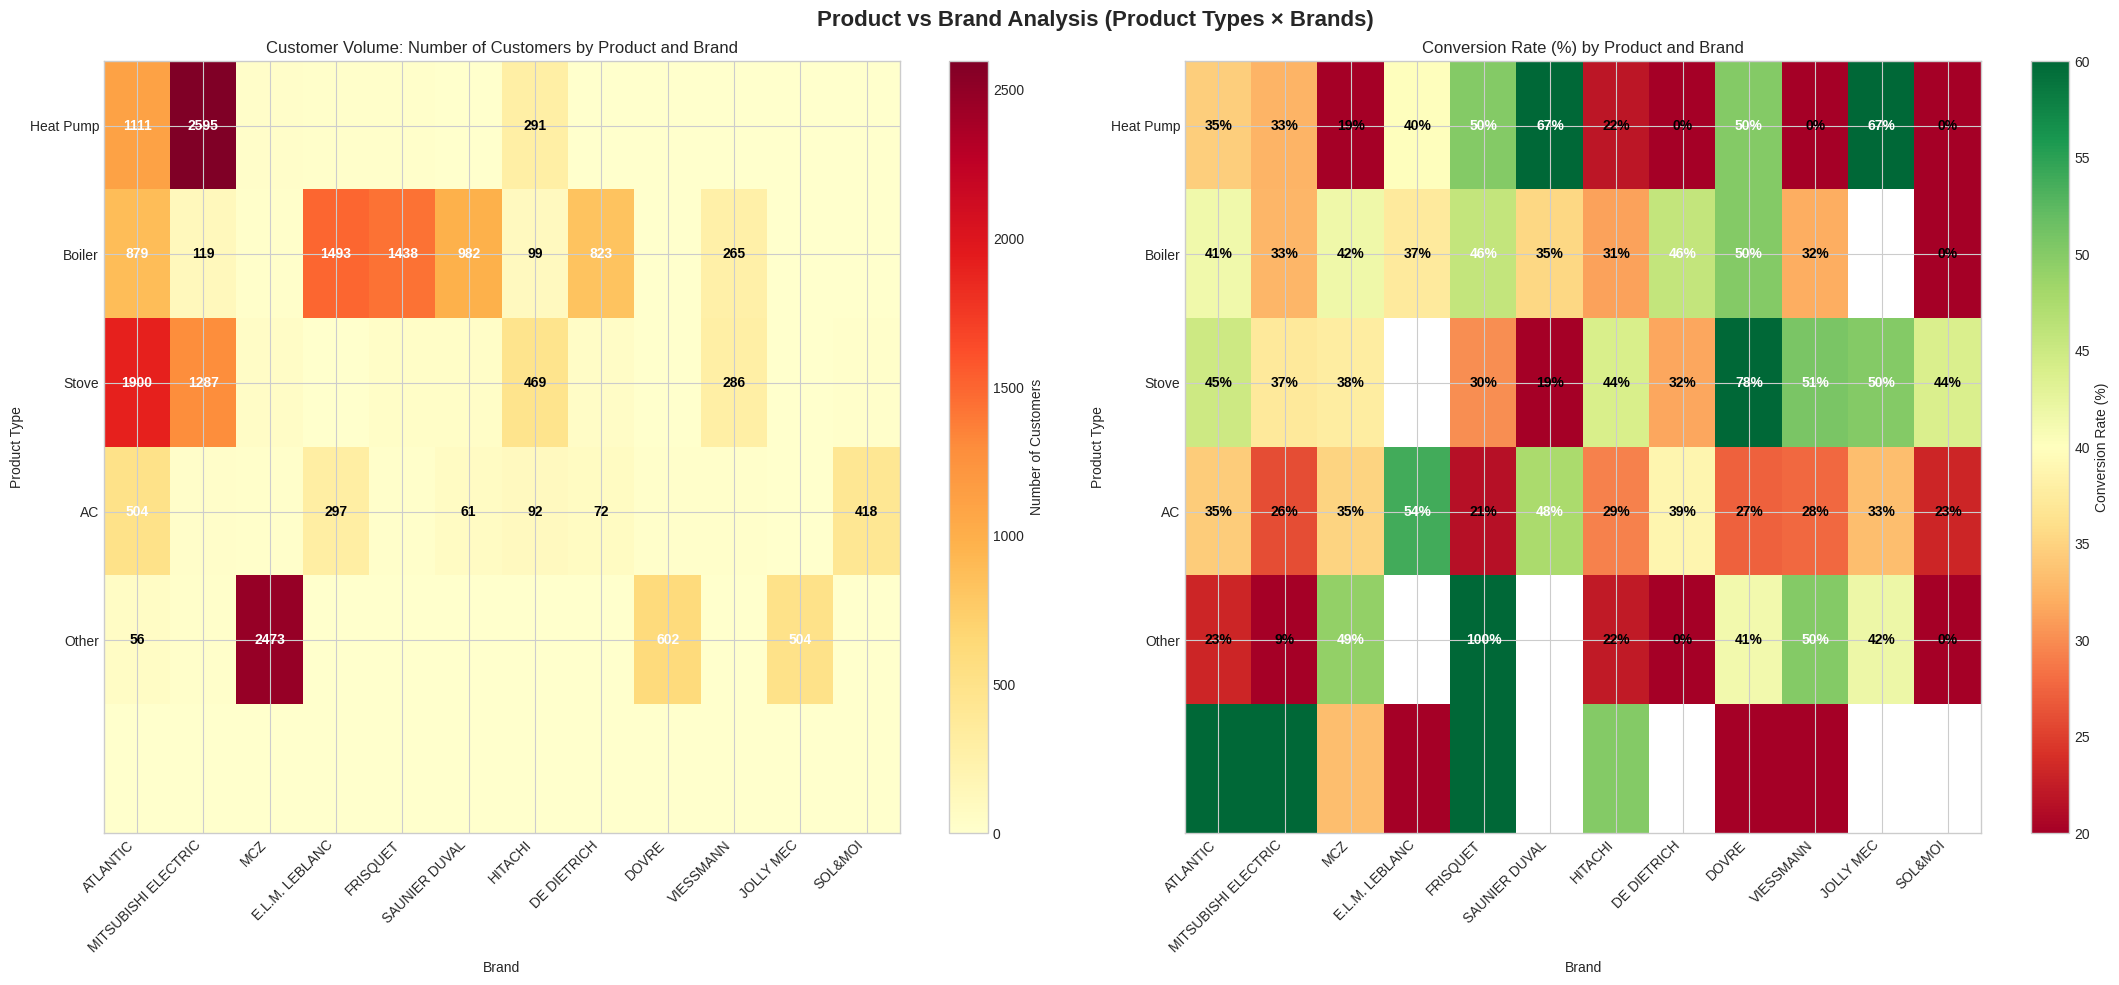


PRODUCT × BRAND ANALYSIS

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_brand               ATLANTIC  MITSUBISHI ELECTRIC   MCZ  E.L.M. LEBLANC  FRISQUET  SAUNIER DUVAL  HITACHI  DE DIETRICH  DOVRE  VIESSMANN  JOLLY MEC  SOL&MOI
main_equipment_category                                                                                                                                          
AC                           1111                 2595    21              15        16              9      291            5      2          3          3        1
Boiler                        879                  119    12            1493      1438            982       99          823      6        265          0        2
Heat Pump                    1900                 1287    45               0        40             32      469           41      9        286          2       16
Other                         504        

In [27]:
# Create Product/Brand Heatmap (Product Type as rows, Brand as columns)
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle('Product vs Brand Analysis (Product Types × Brands)', fontsize=16, fontweight='bold')

# ============================================================================
# HEAT MAP 1: Volume (Number of Customers) by Product and Brand
# ============================================================================
ax1 = axes[0]

# Get top brands and product categories
top_brands = customers['main_brand'].value_counts().head(12).index.tolist()
product_cats = ['Heat Pump', 'Boiler', 'Stove', 'AC', 'Other']

# Create a crosstab of product vs brand (counts)
product_brand_counts = pd.crosstab(
    customers['main_equipment_category'], 
    customers['main_brand']
)

# Filter to top brands only
product_brand_counts = product_brand_counts[top_brands]

# Create heatmap (rows = products, columns = brands)
im1 = ax1.imshow(product_brand_counts, cmap='YlOrRd', aspect='auto')
ax1.set_yticks(range(len(product_cats)))
ax1.set_yticklabels(product_cats)
ax1.set_xticks(range(len(top_brands)))
ax1.set_xticklabels(top_brands, rotation=45, ha='right')
ax1.set_xlabel('Brand')
ax1.set_ylabel('Product Type')
ax1.set_title('Customer Volume: Number of Customers by Product and Brand')

# Add colorbar
plt.colorbar(im1, ax=ax1, label='Number of Customers')

# Add value annotations
for i in range(len(product_cats)):
    for j in range(len(top_brands)):
        value = product_brand_counts.iloc[i, j]
        if value > 50:  # Only show larger values
            color = 'white' if value > 500 else 'black'
            ax1.text(j, i, f'{value}', ha='center', va='center', color=color, fontweight='bold')

# ============================================================================
# HEAT MAP 2: Conversion Rate by Product and Brand
# ============================================================================
ax2 = axes[1]

# Create pivot table of conversion rate by product and brand
product_brand_conv = customers.pivot_table(
    values='converted',
    index='main_equipment_category',
    columns='main_brand',
    aggfunc='mean'
) * 100

# Filter to top brands only
product_brand_conv = product_brand_conv[top_brands]

# Create heatmap (rows = products, columns = brands)
im2 = ax2.imshow(product_brand_conv, cmap='RdYlGn', aspect='auto', vmin=20, vmax=60)
ax2.set_yticks(range(len(product_cats)))
ax2.set_yticklabels(product_cats)
ax2.set_xticks(range(len(top_brands)))
ax2.set_xticklabels(top_brands, rotation=45, ha='right')
ax2.set_xlabel('Brand')
ax2.set_ylabel('Product Type')
ax2.set_title('Conversion Rate (%) by Product and Brand')

# Add colorbar
plt.colorbar(im2, ax=ax2, label='Conversion Rate (%)')

# Add value annotations
for i in range(len(product_cats)):
    for j in range(len(top_brands)):
        value = product_brand_conv.iloc[i, j]
        if not np.isnan(value):
            color = 'white' if value > 45 else 'black'
            ax2.text(j, i, f'{value:.0f}%', ha='center', va='center', color=color, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# Detailed Analysis Tables
# ============================================================================
print("\n" + "="*80)
print("PRODUCT × BRAND ANALYSIS")
print("="*80)

# Table 1: Volume (Customer Count)
print("\n📊 CUSTOMER VOLUME (Number of Customers):")
print("-" * 80)
volume_table = product_brand_counts.copy()
print(volume_table.to_string())

# Table 2: Conversion Rates
print("\n" + "="*80)
print("📈 CONVERSION RATES (%):")
print("-" * 80)
conv_table = product_brand_conv.round(1)
print(conv_table.to_string())

# Table 3: Best Brand for Each Product
print("\n" + "="*80)
print("🏆 BEST BRAND BY PRODUCT TYPE")
print("-" * 80)

for product in product_cats:
    if product in product_brand_conv.index:
        product_data = product_brand_conv.loc[product].dropna().sort_values(ascending=False)
        if len(product_data) > 0:
            best_brand = product_data.index[0]
            best_conv = product_data.iloc[0]
            volume = product_brand_counts.loc[product, best_brand]
            
            print(f"\n{product}:")
            print(f"  Best brand: {best_brand}")
            print(f"  Conversion: {best_conv:.1f}%")
            print(f"  Customers: {volume:,}")
            
            # Show top 3
            print(f"  Top 3 brands:")
            for i in range(min(3, len(product_data))):
                brand = product_data.index[i]
                conv = product_data.iloc[i]
                vol = product_brand_counts.loc[product, brand]
                print(f"    {i+1}. {brand}: {conv:.1f}% (n={vol:,})")

# Table 4: Best Product for Each Brand
print("\n" + "="*80)
print("🏆 BEST PRODUCT BY BRAND")
print("-" * 80)

for brand in top_brands[:8]:  # Top 8 brands
    if brand in product_brand_conv.columns:
        brand_data = product_brand_conv[brand].dropna().sort_values(ascending=False)
        if len(brand_data) > 0:
            best_product = brand_data.index[0]
            best_conv = brand_data.iloc[0]
            volume = product_brand_counts.loc[best_product, brand]
            
            print(f"\n{brand}:")
            print(f"  Best product: {best_product}")
            print(f"  Conversion: {best_conv:.1f}%")
            print(f"  Customers: {volume:,}")
            
            # Show all products for this brand
            print(f"  All products:")
            for product in brand_data.index:
                conv = brand_data[product]
                vol = product_brand_counts.loc[product, brand]
                print(f"    {product}: {conv:.1f}% (n={vol:,})")

# ============================================================================
# Strategic Insights
# ============================================================================
print("\n" + "="*80)
print("💡 STRATEGIC INSIGHTS")
print("="*80)

# Find where each brand dominates
print("\nBrand Dominance by Product Category:")
for product in product_cats:
    if product in product_brand_counts.index:
        # Find brand with highest volume in this product
        top_volume_brand = product_brand_counts.loc[product].idxmax()
        top_volume = product_brand_counts.loc[product].max()
        top_volume_share = (top_volume / product_brand_counts.loc[product].sum()) * 100
        
        # Find brand with highest conversion in this product
        if product in product_brand_conv.index:
            top_conv_brand = product_brand_conv.loc[product].dropna().idxmax()
            top_conv = product_brand_conv.loc[product].dropna().max()
            
            print(f"\n{product}:")
            print(f"  Volume leader: {top_volume_brand} ({top_volume:,} customers, {top_volume_share:.1f}% share)")
            print(f"  Conversion leader: {top_conv_brand} ({top_conv:.1f}%)")

# Check for "LBC" specifically if it exists
lbc_brands = [b for b in top_brands if 'LBC' in b.upper()]
if lbc_brands:
    print("\n" + "="*80)
    print("🔍 LBC BRAND ANALYSIS")
    print("="*80)
    for lbc in lbc_brands:
        print(f"\n{lbc}:")
        if lbc in product_brand_conv.columns:
            lbc_data = product_brand_conv[lbc].dropna().sort_values(ascending=False)
            print(f"  Best product: {lbc_data.index[0]} ({lbc_data.iloc[0]:.1f}%)")
            for product in lbc_data.index:
                vol = product_brand_counts.loc[product, lbc]
                print(f"    {product}: {lbc_data[product]:.1f}% (n={vol:,})")


Top 15 agencies by customer volume:
  VB Gaz: 3,029 customers, 42.3% conversion
  Agence Caen: 2,805 customers, 42.4% conversion
  Chauffage du Nord: 2,335 customers, 38.4% conversion
  SBF Energies: 2,035 customers, 34.7% conversion
  Agence Rouen: 1,880 customers, 36.1% conversion
  Roussin Energies: 1,783 customers, 35.3% conversion
  Agence Valognes: 1,493 customers, 43.6% conversion
  Agence Cherbourg: 1,265 customers, 47.7% conversion
  Agence Avranches: 907 customers, 40.1% conversion
  Agence Evreux: 829 customers, 50.2% conversion
  SMEC: 797 customers, 35.1% conversion
  SMT Energies: 674 customers, 41.5% conversion
  Mure Energies: 645 customers, 34.0% conversion
  Agence Les Moitiers d'Allonne: 595 customers, 38.0% conversion
  Aujard: 594 customers, 30.1% conversion


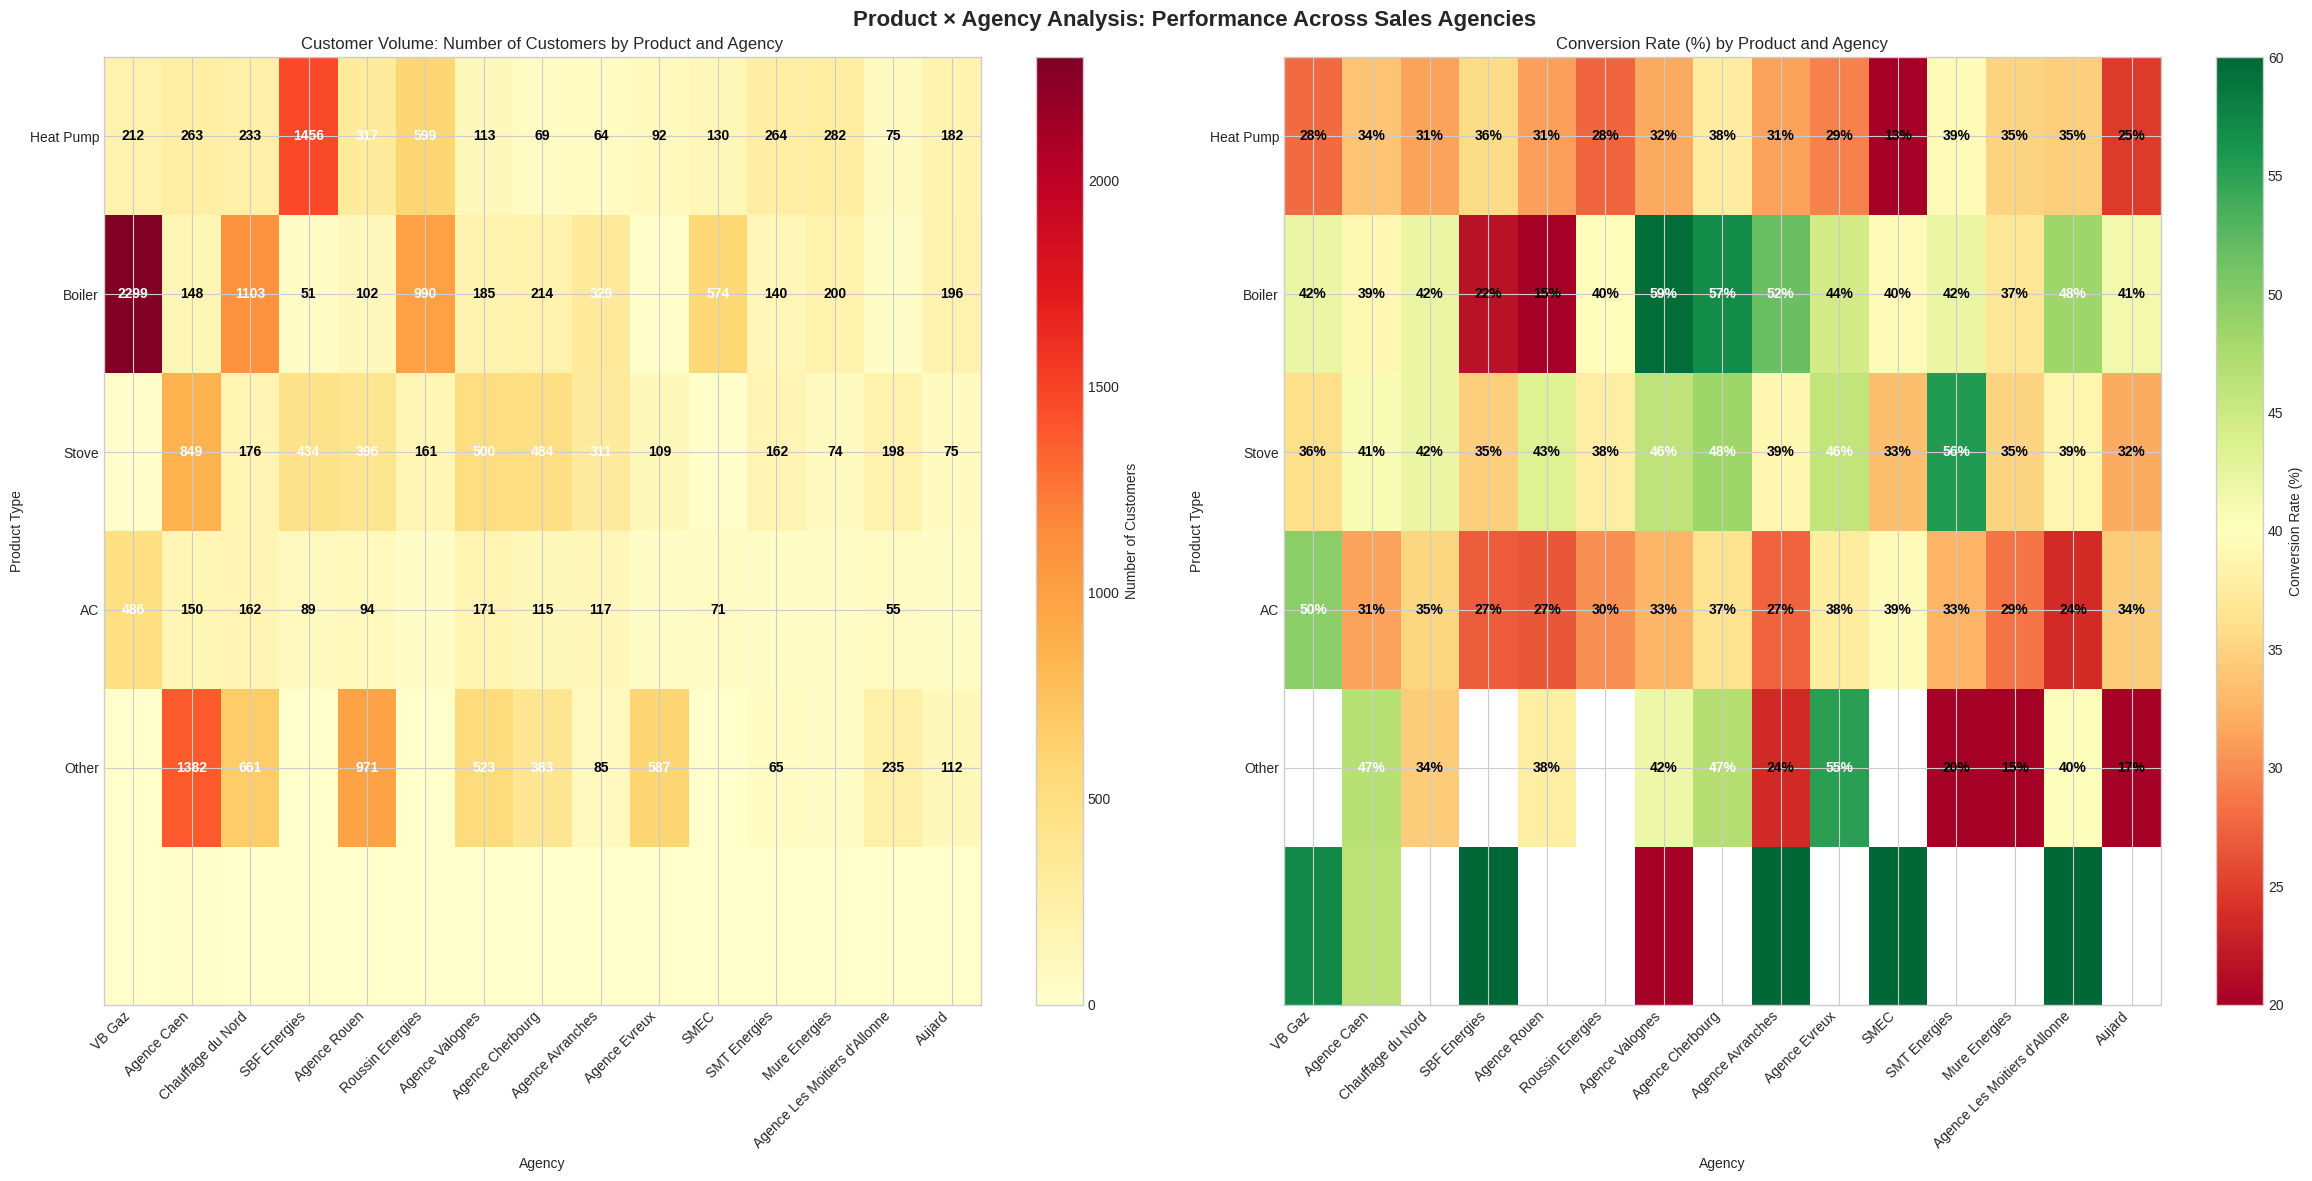


PRODUCT × AGENCY ANALYSIS

📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:
----------------------------------------------------------------------------------------------------
main_agency              VB Gaz  Agence Caen  Chauffage du Nord  SBF Energies  Agence Rouen  Roussin Energies  Agence Valognes  Agence Cherbourg  Agence Avranches  Agence Evreux  SMEC  SMT Energies  Mure Energies  Agence Les Moitiers d'Allonne  Aujard
main_equipment_category                                                                                                                                                                                                                                    
AC                          212          263                233          1456           317               599              113                69                64             92   130           264            282                             75     182
Boiler                     2299          148               1103           

In [28]:
# Create Product/Agency Heatmap (Product Type × Agency)
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
fig.suptitle('Product × Agency Analysis: Performance Across Sales Agencies', fontsize=16, fontweight='bold')

# Get top agencies by volume
top_agencies = customers['main_agency'].value_counts().head(15).index.tolist()
product_cats = ['Heat Pump', 'Boiler', 'Stove', 'AC', 'Other']

print(f"\nTop 15 agencies by customer volume:")
for agency in top_agencies:
    count = customers[customers['main_agency'] == agency].shape[0]
    conv = customers[customers['main_agency'] == agency]['converted'].mean() * 100
    print(f"  {agency}: {count:,} customers, {conv:.1f}% conversion")

# ============================================================================
# HEAT MAP 1: Volume (Number of Customers) by Product and Agency
# ============================================================================
ax1 = axes[0]

# Create a crosstab of product vs agency (counts)
product_agency_counts = pd.crosstab(
    customers['main_equipment_category'], 
    customers['main_agency']
)

# Filter to top agencies only
product_agency_counts = product_agency_counts[top_agencies]

# Create heatmap (rows = products, columns = agencies)
im1 = ax1.imshow(product_agency_counts, cmap='YlOrRd', aspect='auto')
ax1.set_yticks(range(len(product_cats)))
ax1.set_yticklabels(product_cats)
ax1.set_xticks(range(len(top_agencies)))
ax1.set_xticklabels(top_agencies, rotation=45, ha='right')
ax1.set_xlabel('Agency')
ax1.set_ylabel('Product Type')
ax1.set_title('Customer Volume: Number of Customers by Product and Agency')

# Add colorbar
plt.colorbar(im1, ax=ax1, label='Number of Customers')

# Add value annotations for larger volumes
for i in range(len(product_cats)):
    for j in range(len(top_agencies)):
        value = product_agency_counts.iloc[i, j]
        if value > 50:  # Only show larger values
            color = 'white' if value > 300 else 'black'
            ax1.text(j, i, f'{value}', ha='center', va='center', color=color, fontweight='bold')

# ============================================================================
# HEAT MAP 2: Conversion Rate by Product and Agency
# ============================================================================
ax2 = axes[1]

# Create pivot table of conversion rate by product and agency
product_agency_conv = customers.pivot_table(
    values='converted',
    index='main_equipment_category',
    columns='main_agency',
    aggfunc='mean'
) * 100

# Filter to top agencies only
product_agency_conv = product_agency_conv[top_agencies]

# Create heatmap (rows = products, columns = agencies)
im2 = ax2.imshow(product_agency_conv, cmap='RdYlGn', aspect='auto', vmin=20, vmax=60)
ax2.set_yticks(range(len(product_cats)))
ax2.set_yticklabels(product_cats)
ax2.set_xticks(range(len(top_agencies)))
ax2.set_xticklabels(top_agencies, rotation=45, ha='right')
ax2.set_xlabel('Agency')
ax2.set_ylabel('Product Type')
ax2.set_title('Conversion Rate (%) by Product and Agency')

# Add colorbar
plt.colorbar(im2, ax=ax2, label='Conversion Rate (%)')

# Add value annotations
for i in range(len(product_cats)):
    for j in range(len(top_agencies)):
        value = product_agency_conv.iloc[i, j]
        if not np.isnan(value):
            color = 'white' if value > 45 else 'black'
            ax2.text(j, i, f'{value:.0f}%', ha='center', va='center', color=color, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# Detailed Analysis Tables
# ============================================================================
print("\n" + "="*80)
print("PRODUCT × AGENCY ANALYSIS")
print("="*80)

# Table 1: Volume (Customer Count)
print("\n📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:")
print("-" * 100)
volume_table = product_agency_counts.copy()
print(volume_table.to_string())

# Table 2: Conversion Rates
print("\n" + "="*80)
print("📈 CONVERSION RATES (%) BY PRODUCT AND AGENCY:")
print("-" * 100)
conv_table = product_agency_conv.round(1)
print(conv_table.to_string())

# Table 3: Best Agency for Each Product
print("\n" + "="*80)
print("🏆 BEST AGENCY BY PRODUCT TYPE")
print("-" * 100)

for product in product_cats:
    if product in product_agency_conv.index:
        product_data = product_agency_conv.loc[product].dropna().sort_values(ascending=False)
        if len(product_data) > 0:
            best_agency = product_data.index[0]
            best_conv = product_data.iloc[0]
            volume = product_agency_counts.loc[product, best_agency]
            
            print(f"\n{product}:")
            print(f"  Best agency: {best_agency}")
            print(f"  Conversion: {best_conv:.1f}%")
            print(f"  Customers: {volume:,}")
            
            # Show top 3 agencies
            print(f"  Top 3 agencies:")
            for i in range(min(3, len(product_data))):
                agency = product_data.index[i]
                conv = product_data.iloc[i]
                vol = product_agency_counts.loc[product, agency]
                print(f"    {i+1}. {agency}: {conv:.1f}% (n={vol:,})")

# Table 4: Best Product for Each Agency
print("\n" + "="*80)
print("🏆 BEST PRODUCT BY AGENCY")
print("-" * 100)

for agency in top_agencies[:10]:  # Top 10 agencies
    if agency in product_agency_conv.columns:
        agency_data = product_agency_conv[agency].dropna().sort_values(ascending=False)
        if len(agency_data) > 0:
            best_product = agency_data.index[0]
            best_conv = agency_data.iloc[0]
            volume = product_agency_counts.loc[best_product, agency]
            
            print(f"\n{agency}:")
            print(f"  Best product: {best_product}")
            print(f"  Conversion: {best_conv:.1f}%")
            print(f"  Customers: {volume:,}")
            
            # Show all products for this agency
            print(f"  All products:")
            for product in agency_data.index:
                conv = agency_data[product]
                vol = product_agency_counts.loc[product, agency]
                print(f"    {product}: {conv:.1f}% (n={vol:,})")

# ============================================================================
# Agency Performance Summary
# ============================================================================
print("\n" + "="*80)
print("📊 AGENCY PERFORMANCE SUMMARY")
print("="*80)

agency_summary = customers.groupby('main_agency').agg({
    'converted': ['mean', 'count'],
    'ever_bought_heat_pump': 'mean',
    'had_subsidy_issue': 'mean',
    'avg_out_of_pocket': 'mean'
}).round(3)

agency_summary.columns = ['conversion_rate', 'customer_count', 'heat_pump_pct', 'subsidy_issue_pct', 'avg_price']
agency_summary['conversion_rate'] = agency_summary['conversion_rate'] * 100
agency_summary['heat_pump_pct'] = agency_summary['heat_pump_pct'] * 100
agency_summary['subsidy_issue_pct'] = agency_summary['subsidy_issue_pct'] * 100
agency_summary = agency_summary.sort_values('customer_count', ascending=False).head(15)

print("\nTop 15 agencies by volume:")
print(agency_summary.to_string())

# ============================================================================
# Strategic Insights
# ============================================================================
print("\n" + "="*80)
print("💡 STRATEGIC INSIGHTS")
print("="*80)

# Find which agency excels at each product
print("\nAgency Excellence by Product Category:")
for product in product_cats:
    if product in product_agency_conv.index:
        # Find agency with highest conversion for this product
        if product in product_agency_conv.index:
            top_conv_agency = product_agency_conv.loc[product].dropna().idxmax()
            top_conv = product_agency_conv.loc[product].dropna().max()
            volume = product_agency_counts.loc[product, top_conv_agency]
            
            print(f"\n{product}:")
            print(f"  Conversion leader: {top_conv_agency} ({top_conv:.1f}%, n={volume:,})")

# Find agencies with highest heat pump conversion
print("\n" + "="*80)
print("🔥 HEAT PUMP SPECIALISTS")
print("="*80)

heat_pump_agencies = product_agency_conv.loc['Heat Pump'].dropna().sort_values(ascending=False).head(5)
print("\nTop 5 agencies for Heat Pump conversion:")
for agency, conv in heat_pump_agencies.items():
    volume = product_agency_counts.loc['Heat Pump', agency]
    print(f"  {agency}: {conv:.1f}% (n={volume:,})")


📊 COMPREHENSIVE TEMPORAL COMPARISON

------------------------------------------------------------
1. Q1-ONLY COMPARISON (Apples-to-Apples)
------------------------------------------------------------

Q1 Performance by Year:
      converted  ever_bought_heat_pump  avg_out_of_pocket  numero_compte
year                                                                    
2023       44.0                   33.3          11766.113            981
2024       41.7                   24.3           8095.221           1773
2025       39.3                   16.6           7413.449           2487
2026       15.5                   17.3           7299.867            624

------------------------------------------------------------
2. FULL YEAR COMPARISON (Complete Years Only)
------------------------------------------------------------

Full Year Performance:
      converted  ever_bought_heat_pump  avg_out_of_pocket  numero_compte
year                                                                  

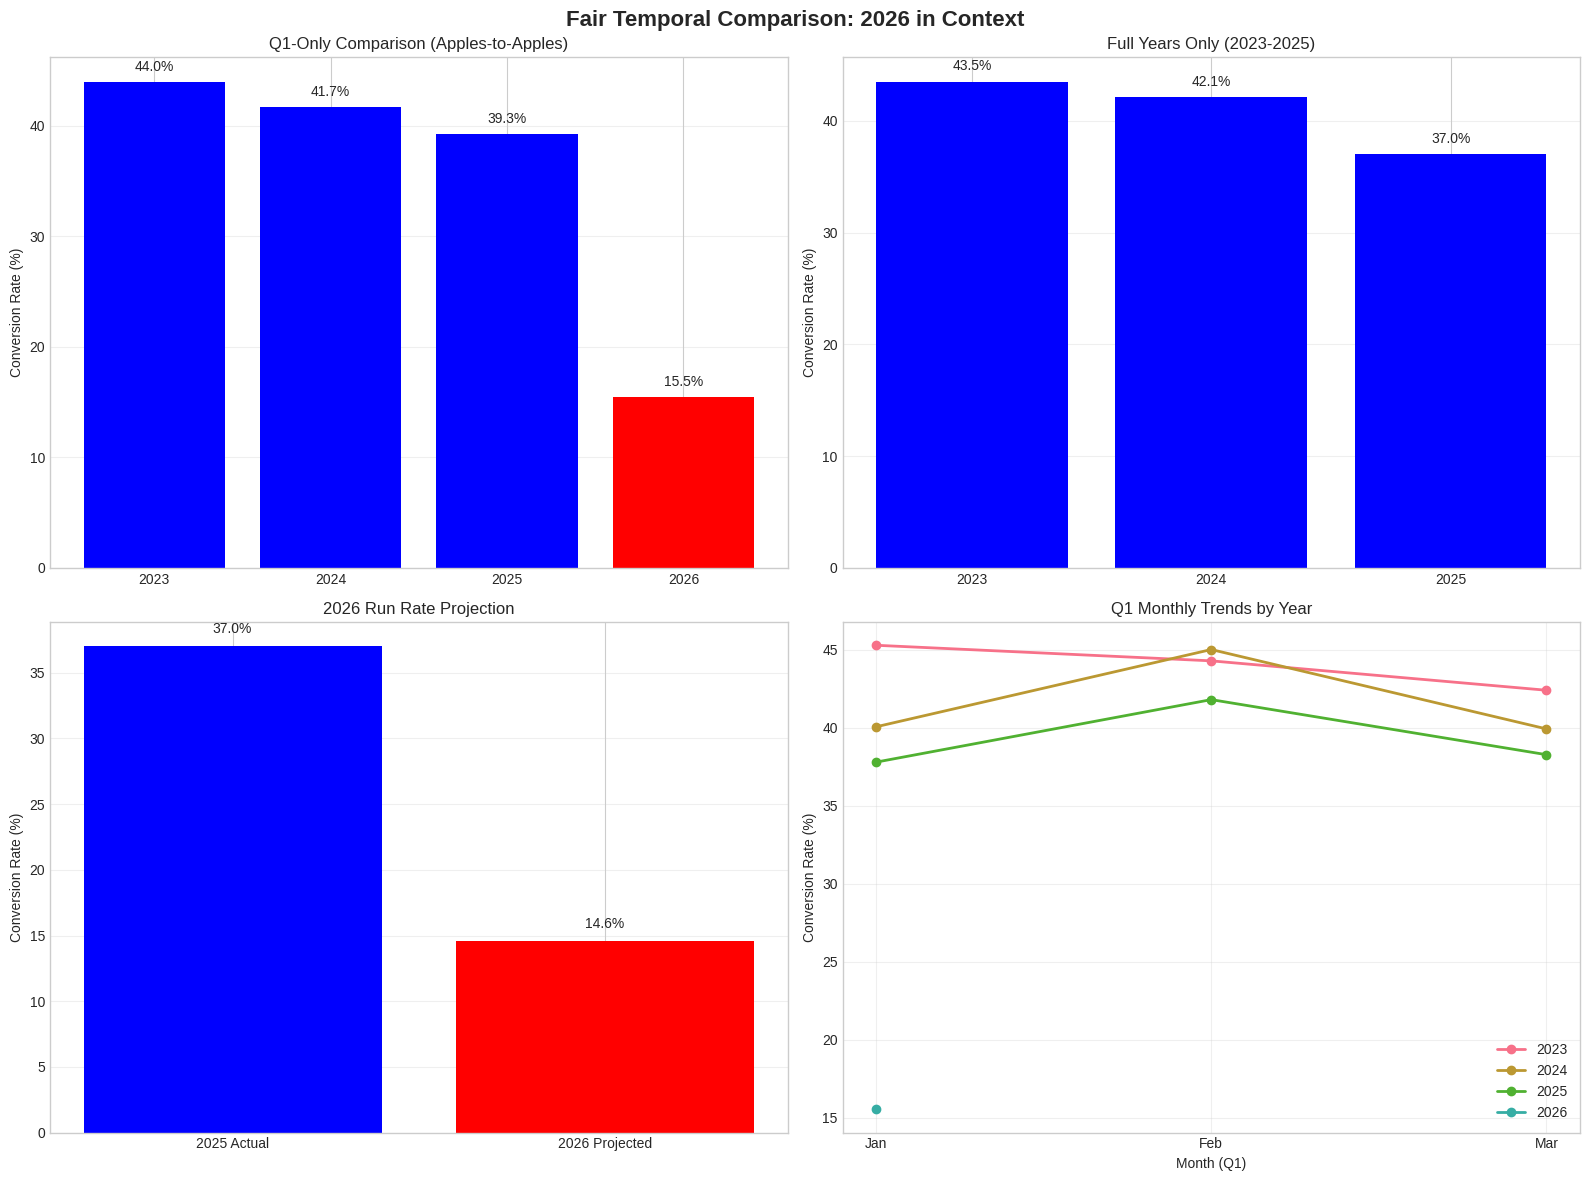

In [29]:
# ============================================================================
# COMPREHENSIVE TEMPORAL COMPARISON
# ============================================================================
print("\n" + "="*80)
print("📊 COMPREHENSIVE TEMPORAL COMPARISON")
print("="*80)

# 1. Q1-ONLY COMPARISON (Fair apples-to-apples)
print("\n" + "-"*60)
print("1. Q1-ONLY COMPARISON (Apples-to-Apples)")
print("-"*60)

q1_comparison = customers[customers['quarter'] == 1].groupby('year').agg({
    'converted': 'mean',
    'ever_bought_heat_pump': 'mean',
    'avg_out_of_pocket': 'mean',
    'numero_compte': 'count'
}).round(3)

q1_comparison['converted'] = q1_comparison['converted'] * 100
q1_comparison['ever_bought_heat_pump'] = q1_comparison['ever_bought_heat_pump'] * 100
print("\nQ1 Performance by Year:")
print(q1_comparison.to_string())

# 2. FULL YEAR COMPARISON (Complete years only)
print("\n" + "-"*60)
print("2. FULL YEAR COMPARISON (Complete Years Only)")
print("-"*60)

full_year_comparison = customers[customers['year'].isin([2023, 2024, 2025])].groupby('year').agg({
    'converted': 'mean',
    'ever_bought_heat_pump': 'mean',
    'avg_out_of_pocket': 'mean',
    'numero_compte': 'count'
}).round(3)

full_year_comparison['converted'] = full_year_comparison['converted'] * 100
full_year_comparison['ever_bought_heat_pump'] = full_year_comparison['ever_bought_heat_pump'] * 100
print("\nFull Year Performance:")
print(full_year_comparison.to_string())

# 3. 2026 RUN RATE PROJECTION
print("\n" + "-"*60)
print("3. 2026 RUN RATE PROJECTION")
print("-"*60)

if 2025 in q1_comparison.index and 2026 in q1_comparison.index:
    q1_2025_conv = q1_comparison.loc[2025, 'converted']
    q1_2026_conv = q1_comparison.loc[2026, 'converted']
    
    full_2025_conv = customers[customers['year'] == 2025]['converted'].mean() * 100
    
    # Q1 typically represents what % of annual pattern?
    q1_share = q1_2025_conv / full_2025_conv
    projected_2026 = q1_2026_conv / q1_share
    
    print(f"\n📈 2026 Projection (based on Q1 run rate):")
    print(f"  Q1 2025 conversion: {q1_2025_conv:.1f}%")
    print(f"  Full 2025 conversion: {full_2025_conv:.1f}%")
    print(f"  Q1 represents {q1_share:.1%} of annual pattern")
    print(f"  Q1 2026 conversion: {q1_2026_conv:.1f}%")
    print(f"  → Projected full 2026: {projected_2026:.1f}%")
    print(f"  → vs 2025 actual: {full_2025_conv:.1f}%")
    print(f"  → Change: {projected_2026 - full_2025_conv:+.1f} points")

# 4. MONTHLY TREND (Most granular)
print("\n" + "-"*60)
print("4. MONTHLY TREND (2023-2026)")
print("-"*60)

# Create monthly trend data
monthly_trend = customers.groupby(['year', 'month'])['converted'].mean().unstack() * 100
print("\nMonthly conversion rates (%):")
print(monthly_trend.round(1).to_string())

# 5. CUMULATIVE 2026 VS PRIOR YEARS
print("\n" + "-"*60)
print("5. CUMULATIVE PROGRESS: 2026 vs Prior Years")
print("-"*60)

# Get cumulative data up to current date in 2026
current_date_2026 = pd.Timestamp('2026-03-18')  # Assuming today's date
days_in_2026 = (current_date_2026 - pd.Timestamp('2026-01-01')).days + 1

for year in [2023, 2024, 2025]:
    year_end = pd.Timestamp(f'{year}-12-31')
    year_start = pd.Timestamp(f'{year}-01-01')
    
    # Get same period in prior year (first X days)
    prior_year_period = customers[
        (customers['year'] == year) & 
        (pd.to_datetime(customers['first_quote_date']) <= year_start + pd.Timedelta(days=days_in_2026-1))
    ]
    
    if len(prior_year_period) > 0:
        print(f"\nFirst {days_in_2026} days of {year}:")
        print(f"  Customers: {len(prior_year_period):,}")
        print(f"  Conversion: {prior_year_period['converted'].mean()*100:.1f}%")
        print(f"  Heat pumps: {prior_year_period['ever_bought_heat_pump'].mean()*100:.1f}%")

# ============================================================================
# VISUALIZATION: Fair Comparison
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Fair Temporal Comparison: 2026 in Context', fontsize=16, fontweight='bold')

# Plot 1: Q1-only comparison
ax1 = axes[0, 0]
q1_years = q1_comparison.index.tolist()
q1_conv = q1_comparison['converted'].values
bars = ax1.bar([str(y) for y in q1_years], q1_conv, color=['blue', 'blue', 'blue', 'red'])
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('Q1-Only Comparison (Apples-to-Apples)')
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, q1_conv):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.1f}%', ha='center')

# Plot 2: Full years only
ax2 = axes[0, 1]
full_years = full_year_comparison.index.tolist()
full_conv = full_year_comparison['converted'].values
bars = ax2.bar([str(y) for y in full_years], full_conv, color='blue')
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_title('Full Years Only (2023-2025)')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, full_conv):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.1f}%', ha='center')

# Plot 3: 2026 Projection vs 2025
ax3 = axes[1, 0]
if 'projected_2026' in locals():
    comp_data = [full_2025_conv, projected_2026]
    bars = ax3.bar(['2025 Actual', '2026 Projected'], comp_data, color=['blue', 'red', 'green'])
    ax3.set_ylabel('Conversion Rate (%)')
    ax3.set_title('2026 Run Rate Projection')
    ax3.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, comp_data):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.1f}%', ha='center')

# Plot 4: Monthly trend for Q1
ax4 = axes[1, 1]
q1_months = [1, 2, 3]
for year in [2023, 2024, 2025, 2026]:
    year_q1 = customers[(customers['year'] == year) & (customers['month'].isin(q1_months))]
    monthly_data = year_q1.groupby('month')['converted'].mean() * 100
    ax4.plot(monthly_data.index, monthly_data.values, 'o-', linewidth=2, label=f'{year}')
ax4.set_xlabel('Month (Q1)')
ax4.set_ylabel('Conversion Rate (%)')
ax4.set_title('Q1 Monthly Trends by Year')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_xticks([1, 2, 3])
ax4.set_xticklabels(['Jan', 'Feb', 'Mar'])

plt.tight_layout()
plt.show()